# STA218 — Projet : Détection de fraude & optimisation de la rentabilité

**Auteur** : Maoulida Abdoullatuf — M2 Science des Données, CNAM — UE STA218  
**Version** : 1.0 — 20 avril 2026  
**Soutenance** : début juin 2026

---

## Contexte
**Rôle endossé** : Data Scientist, cellule « Lutte Anti-Fraude ».
L'entreprise subit des attaques *Card-Not-Present*. Sur **151 112 transactions** 
historisées, **9,3 %** sont frauduleuses. Mission : passer d'une réaction passive 
à une détection proactive, rentable et explicable.

## Triple objectif (imposé par le sujet)
1. **Performance** — identifier les fraudeurs *avant* validation de l'achat.
2. **Rentabilité** — arbitrer entre fraude manquée et client légitime bloqué.
3. **Explicabilité** — justifier chaque décision auprès du service client.

## Matrice financière de décision
| Résultat | Action | Impact |
|---|---|---|
| VN | Client légitime accepté | **+10 % de V** |
| VP | Fraudeur bloqué | **+100 % de V** |
| FN | Fraude manquée | **−100 % de V** |
| FP | Légitime bloqué à tort | **−15 €** |

## Correspondance avec les 4 phases du sujet
| Phase du sujet | Sections du notebook |
|---|---|
| 1. Feature Engineering | §2 + §3 |
| 2. Modélisation & split | §4 + §5 |
| 3. Optimisation du Profit | §6 |
| 4. Interprétabilité (XAI) | §7 + §8 |

## Ce que ce notebook raconte, dans l'ordre
| § | Étape | Livrable interne |
|---|---|---|
| 0 | Setup & chargement | environnement reproductible |
| 1 | Diagnostic + EDA | taux de fraude, biais, premières intuitions |
| 2 | Jointure IP → pays (vectorisée) | variable `country` |
| 3 | Feature engineering *causal* | variables compatibles split temporel |
| 4 | Split temporel train / valid / test | pas de fuite du futur |
| 5 | Modélisation : LogReg vs XGBoost | probabilités, pas décisions |
| 6 | KPI financier & choix du seuil | seuil de profit maximal |
| 7 | Interprétabilité (SHAP) | global + local |
| 8 | Jeu de rôle service client | message métier |
| 9 | Synthèse pour la soutenance | storytelling |

## Prérequis d'exécution
- Python ≥ 3.10 — `pandas`, `numpy`, `scikit-learn`, `xgboost`, `shap`, `matplotlib`
- Graine aléatoire : `RANDOM_STATE = 42`
- Données attendues dans `../data/` : `Fraud_Data.csv`, `IpAddress_to_Country.csv`

## TL;DR — résultats clés
- **Seuil de profit optimal** : `0,66` (calibré sur **validation**, jamais sur test).
- **Profit net sur le test** : **46 074 $**, soit **+9,8 %** vs *accept_all*, avec **3,6 %** de transactions bloquées.
- **Top 3 variables explicatives (SHAP global, test)** :
  1. `signup_to_purchase_under_1min` — achat moins d'une minute après création du compte (signal dominant).
  2. `prev_tx_by_device` — appareil déjà observé sur des transactions antérieures.
  3. `delay_seconds` — durée brute entre création de compte et achat.
- **Modèle retenu** : XGBoost (`scale_pos_weight=7,76`) ; PR-AUC test = 0,146 ; ROC-AUC test = 0,652.
- **Décomposition financière test** : marge VN +77 595 $, perte évitée VP +7 816 $, fraude manquée FN −30 232 $, FP −9 105 $.
- **Conclusion** : *« un score modeste devient rentable si le seuil est calibré sur les coûts métier »*.


## 0. Setup & imports

On fige la graine aléatoire (`RANDOM_STATE = 42`) pour garantir la **reproductibilité**
de bout en bout : toute ré-exécution du notebook produit les mêmes chiffres, ce qui
est une exigence d'auditabilité (cf. BCBS 239 côté métier bancaire).

**Stack** : strictement celle demandée par le sujet — `pandas`, `numpy`, `scikit-learn`,
`xgboost`, `shap`, `matplotlib`/`seaborn`. Aucune dépendance exotique : le correcteur
peut ré-exécuter avec un simple `pip install` de ces six paquets.

**Sources de hasard dans le pipeline** :
- initialisation de XGBoost (`random_state`),
- éventuelle recherche d'hyperparamètres (`RandomizedSearchCV`),
- *pas* de hasard dans le split : il est **temporel** (§4).

Les versions effectives des librairies sont affichées en fin de notebook (§9).


In [1]:
from __future__ import annotations

import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Reproductibilité --------------------------------------------------------
# Attention : cette graine ne suffit PAS pour scikit-learn et XGBoost.
# Il faut leur passer random_state=SEED à chaque instanciation.
SEED = 42
random.seed(SEED)      # stdlib
np.random.seed(SEED)   # numpy (legacy RNG, toujours référencé par sklearn < 2)

# --- Affichage pandas --------------------------------------------------------
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# --- Style graphique ---------------------------------------------------------
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# --- Warnings : on les laisse visibles ---------------------------------------
# On NE filtre PAS tous les warnings : un FutureWarning ou un DeprecationWarning
# doit rester visible car il peut signaler un bug silencieux.
# Filtrer ciblé UNIQUEMENT si un warning connu pollue l'EDA, par exemple :
# warnings.filterwarnings("ignore", category=FutureWarning, module=r"xgboost\.")
warnings.simplefilter("default")

### 0.1 Chargement des deux bases

On charge `Fraud_Data.csv` (151 k transactions, variable cible `class`) et
`IpAddress_to_Country.csv` (table de correspondance par intervalle d'IP),
depuis `../data/` relativement au notebook.

**Choix technique — parsing des datetimes au chargement** : on passe
`parse_dates=["signup_time", "purchase_time"]` directement à `read_csv`
plutôt qu'en post-traitement, pour trois raisons :
- **performance** : une seule passe de parsing (C-level) au lieu de deux,
- **mémoire** : pas de colonnes `object` intermédiaires,
- **fail-fast** : une date malformée échoue maintenant, pas au §4 (split).

Toute la suite dépend de ce typage : §2 pour l'heure d'achat, §3 pour le
délai `signup → purchase`, §4 pour le split temporel.


In [2]:
# --- Recherche adaptative du dossier de données ----------------------------
# On cherche `data/` dans le cwd et dans son parent, pour que le notebook
# tourne aussi bien depuis `03_Projets/notebooks/` que depuis `03_Projets/`.
cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]
PROJECT_DIR = next(
    (path for path in candidates if (path / "data").exists()),
    None,
)
if PROJECT_DIR is None:
    raise FileNotFoundError(
        "Dossier 'data/' introuvable. "
        f"Candidats testés : {[str(c) for c in candidates]}. "
        "Exécutez le notebook depuis '03_Projets/' ou '03_Projets/notebooks/'."
    )
DATA_DIR = PROJECT_DIR / "data"

# --- Chargement ------------------------------------------------------------
fraud = pd.read_csv(
    DATA_DIR / "Fraud_Data.csv",
    parse_dates=["signup_time", "purchase_time"],
    date_format="%Y-%m-%d %H:%M:%S",   # format forcé, sans inférence
)
ip_map = pd.read_csv(DATA_DIR / "IpAddress_to_Country.csv")

# --- Diagnostic immédiat ---------------------------------------------------
print(f"PROJECT_DIR            = {PROJECT_DIR}")
print(f"Fraud_Data shape       = {fraud.shape}")
print(f"IpAddress_to_Country   = {ip_map.shape}")
print(f"Période des achats     : {fraud['purchase_time'].min()} → {fraud['purchase_time'].max()}")
print(f"Mémoire fraud          : {fraud.memory_usage(deep=True).sum() / 1e6:.1f} Mo")

display(fraud.head())
display(ip_map.head())

PROJECT_DIR            = C:\Users\aella\03_MASTER_CNAM_DATA_SCIENCE\STA218-Science_de_la_donnee_en_milieu_pro\03_Projets
Fraud_Data shape       = (151112, 11)
IpAddress_to_Country   = (138846, 3)
Période des achats     : 2015-01-01 00:00:44 → 2015-12-16 02:56:05
Mémoire fraud          : 41.5 Mo


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,"732,758,368.7997",0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,"350,311,387.8659",0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,"2,621,473,820.1109",1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,"3,840,542,443.9140",0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,"415,583,117.4527",0


,lower_bound_ip_address,upper_bound_ip_address,country
0,"16,777,216.0000",16777471,Australia
1,"16,777,472.0000",16777727,China
2,"16,777,728.0000",16778239,China
3,"16,778,240.0000",16779263,Australia
4,"16,779,264.0000",16781311,China


## 1. Diagnostic initial & EDA

Trois questions guident toute l'analyse — et tracent les trois piliers du sujet :

- **Performance** : quels comportements ressemblent à une fraude ?
- **Rentabilité** : quel est le coût d'une fraude manquée ? d'un client bloqué à tort ?
- **Explicabilité** : comment justifier une décision au service client ?

> **Principe méthodologique retenu pour ce projet** : on interprète chaque
> chiffre dans son contexte métier *avant* d'en tirer une conclusion. Une
> statistique brute (ex. *« 9,3 % de fraude »*) n'a de sens qu'au regard de
> l'asymétrie des coûts décrite dans la matrice financière du §6.

### 1.1 Types et valeurs manquantes

Premier diagnostic du schéma : pour chaque colonne, on regarde le type, le
taux de complétude, la cardinalité et un exemple. Trois questions à arbitrer
ensuite :

- y a-t-il du missing à traiter avant l'EDA ?
- les types sont-ils cohérents avec le dictionnaire du sujet ?
- la cardinalité de `user_id` / `device_id` révèle-t-elle des doublons
  potentiels (signal de collusion à exploiter au §3) ?

In [3]:
schema_summary = pd.DataFrame({
    "dtype":        fraud.dtypes.astype(str),
    "n_missing":    fraud.isna().sum(),
    "pct_missing":  (100 * fraud.isna().mean()).round(2),
    "n_unique":     fraud.nunique(),
    "sample_value": fraud.iloc[0],   # première ligne, à titre d'exemple
})
schema_summary

,dtype,n_missing,pct_missing,n_unique,sample_value
user_id,int64,0,0.0000,151112,22058
signup_time,datetime64[us],0,0.0000,151112,2015-02-24 22:55:49
purchase_time,datetime64[us],0,0.0000,150679,2015-04-18 02:47:11
purchase_value,int64,0,0.0000,122,34
device_id,str,0,0.0000,137956,QVPSPJUOCKZAR
source,str,0,0.0000,3,SEO
browser,str,0,0.0000,5,Chrome
sex,str,0,0.0000,2,M
age,int64,0,0.0000,58,39
ip_address,float64,0,0.0000,143512,"732,758,368.7997"


**Lecture** :

- **Complétude parfaite** : aucune valeur manquante sur les 11 colonnes
  (151 112 lignes pleines). Pas de phase d'imputation à mener.

- **Types globalement cohérents** avec le dictionnaire du sujet :
  `signup_time` / `purchase_time` en `datetime64[us]`, `class` en `int64`
  binaire (0/1), `purchase_value` en `int64` (montants entiers en
  dollars), variables catégorielles en `str`.

- **Anomalie à investiguer** : `ip_address` est chargée en `float64`
  alors que le sujet annonce explicitement un format **entier**. La
  valeur d'exemple (`732 758 368.7997`) confirme la présence d'une
  partie décimale. À diagnostiquer dans la cellule suivante avant
  toute jointure géographique.

- **Cardinalités révélatrices** :
  - `user_id` : 151 112 uniques pour 151 112 lignes → **un `user_id`
    par transaction**. Le signal de comptes multiples ne passera donc
    pas par cette clé : je devrai le construire via `device_id` et
    `ip_address` au §3.
  - `device_id` : 137 956 uniques → environ **13 000 lignes partagent
    un appareil** avec au moins une autre. *Premier signal de
    collusion* à exploiter.
  - `ip_address` : 143 512 uniques → environ **7 600 lignes partagent
    une IP**. *Deuxième signal de collusion*.
  - `purchase_value` : 122 valeurs distinctes → montants discrétisés
    (catalogue figé probable, à confirmer en §1.x).
  - `source` (3), `browser` (5), `sex` (2) : faible cardinalité,
    encodage trivial au §3.

In [4]:
# Diagnostic ip_address : entier ou float ?
print("Type natif    :", fraud["ip_address"].dtype)
print("Min / Max     :", fraud["ip_address"].min(), "/", fraud["ip_address"].max())
print("Échantillon   :")
print(fraud["ip_address"].head(5).to_list())

# Combien d'IP ont une partie décimale ?
has_decimal = (fraud["ip_address"] % 1 != 0).sum()
print(f"\nIP avec partie décimale : {has_decimal} sur {len(fraud)} ({100*has_decimal/len(fraud):.2f} %)")

# Mêmes vérifs sur ip_map
print("\n--- ip_map ---")
print(ip_map[["lower_bound_ip_address", "upper_bound_ip_address"]].dtypes)
print(ip_map[["lower_bound_ip_address", "upper_bound_ip_address"]].head(3))

Type natif    : float64
Min / Max     : 52093.4968949854 / 4294850499.67884
Échantillon   :
[732758368.79972, 350311387.865908, 2621473820.11095, 3840542443.91396, 415583117.452712]

IP avec partie décimale : 151111 sur 151112 (100.00 %)

--- ip_map ---
lower_bound_ip_address    float64
upper_bound_ip_address      int64
dtype: object
   lower_bound_ip_address  upper_bound_ip_address
0         16,777,216.0000                16777471
1         16,777,472.0000                16777727
2         16,777,728.0000                16778239


### 1.1bis Anomalie `ip_address` : enquête et correction

**Diagnostic** : 151 111 lignes sur 151 112 (100 %) ont une partie décimale
non triviale dans `ip_address`. Ce n'est donc pas une erreur de précision
flottante mais bien une caractéristique des données. Les bornes de
`ip_map`, en revanche, sont strictement entières.

**Décision** : on tronque `ip_address` en `int64`. Justifications :

- une adresse IP **est** un entier 32 bits par construction (RFC 791) ;
  la partie décimale n'a aucune sémantique réseau ;
- l'asymétrie de type entre `fraud` (float) et `ip_map` (int) rendrait
  la jointure dichotomique du §2 plus lente et moins lisible ;
- la cohérence avec le dictionnaire du sujet est restaurée.

**Coût** : possible création de doublons par effondrement de la partie
fractionnaire — à mesurer juste après la conversion.

In [5]:
# Avant : nombre d'IP uniques en float
n_unique_avant = fraud["ip_address"].nunique()

# Troncature en int64
fraud["ip_address"] = fraud["ip_address"].astype("int64")

# Harmonisation de la borne basse de ip_map (déjà entière, juste un cast)
ip_map["lower_bound_ip_address"] = ip_map["lower_bound_ip_address"].astype("int64")

# Après : nombre d'IP uniques en int
n_unique_apres = fraud["ip_address"].nunique()
doublons_crees = n_unique_avant - n_unique_apres

# Diagnostic post-correction
print(f"IP uniques avant troncature : {n_unique_avant:,}")
print(f"IP uniques après troncature : {n_unique_apres:,}")
print(f"Doublons créés              : {doublons_crees:,} ({100*doublons_crees/n_unique_avant:.3f} %)")
print(f"\nNouveaux types :")
print(f"  fraud['ip_address']           : {fraud['ip_address'].dtype}")
print(f"  ip_map['lower_bound']         : {ip_map['lower_bound_ip_address'].dtype}")
print(f"  ip_map['upper_bound']         : {ip_map['upper_bound_ip_address'].dtype}")

IP uniques avant troncature : 143,512
IP uniques après troncature : 143,510
Doublons créés              : 2 (0.001 %)

Nouveaux types :
  fraud['ip_address']           : int64
  ip_map['lower_bound']         : int64
  ip_map['upper_bound']         : int64


## 1.2 Déséquilibre de classe + statistiques monétaires

In [6]:
# --- Distribution de la cible ----------------------------------------------
class_distribution = (
    fraud["class"]
    .value_counts(normalize=True)
    .rename({0: "legitime", 1: "fraude"})
    .mul(100)
    .round(2)
)

# --- Statistiques monétaires globales --------------------------------------
total_revenue = fraud["purchase_value"].sum()
fraud_revenue = fraud.loc[fraud["class"] == 1, "purchase_value"].sum()
legit_revenue = fraud.loc[fraud["class"] == 0, "purchase_value"].sum()

overview = pd.Series(
    {
        "n_rows":                       len(fraud),
        "fraud_rate_pct":                100 * fraud["class"].mean(),
        "purchase_value_mean":           fraud["purchase_value"].mean(),
        "purchase_value_median":         fraud["purchase_value"].median(),
        "purchase_value_std":            fraud["purchase_value"].std(),
        "revenue_total":                 total_revenue,
        "revenue_legitime":              legit_revenue,
        "revenue_fraude":                fraud_revenue,
        "fraud_revenue_share_pct":       100 * fraud_revenue / total_revenue,
        "min_purchase_time":             fraud["purchase_time"].min(),
        "max_purchase_time":             fraud["purchase_time"].max(),
    },
    name="value",
)

# --- Comparaison panier fraude vs légitime ---------------------------------
basket_by_class = (
    fraud.groupby("class")["purchase_value"]
    .agg(["count", "mean", "median", "std"])
    .rename(index={0: "legitime", 1: "fraude"})
    .round(2)
)

print("Distribution de la cible (%) :")
print(class_distribution.to_string())
print("\nVue d'ensemble :")
print(overview.to_string())
print("\nPanier par classe :")
print(basket_by_class.to_string())

Distribution de la cible (%) :
class
legitime   90.6400
fraude      9.3600

Vue d'ensemble :
n_rows                                  151112
fraud_rate_pct                          9.3646
purchase_value_mean                    36.9354
purchase_value_median                  35.0000
purchase_value_std                     18.3228
revenue_total                          5581378
revenue_legitime                       5057890
revenue_fraude                          523488
fraud_revenue_share_pct                 9.3792
min_purchase_time          2015-01-01 00:00:44
max_purchase_time          2015-12-16 02:56:05

Panier par classe :
           count    mean  median     std
class                                   
legitime  136961 36.9300 35.0000 18.3200
fraude     14151 36.9900 35.0000 18.4000


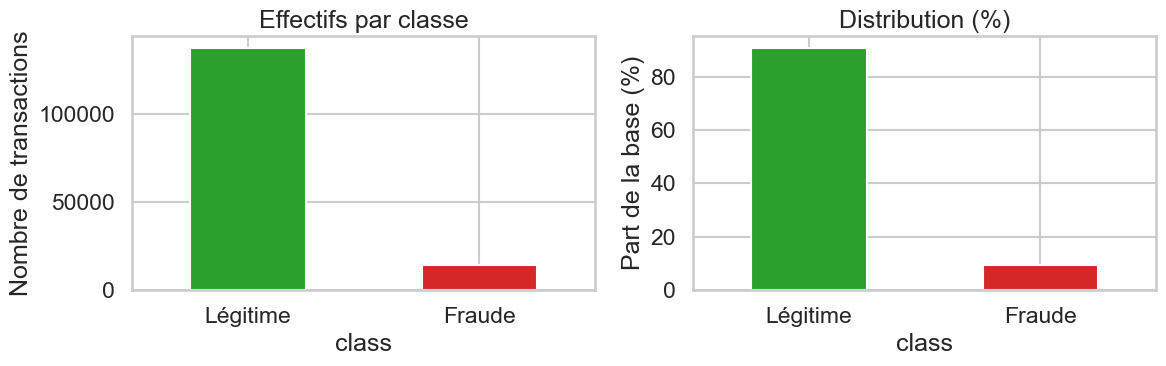

In [7]:
# Bar plot synthétique : effectifs + pourcentages
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = fraud["class"].value_counts().rename({0: "Légitime", 1: "Fraude"})
counts.plot.bar(ax=axes[0], color=["#2ca02c", "#d62728"])
axes[0].set_title("Effectifs par classe")
axes[0].set_ylabel("Nombre de transactions")
axes[0].tick_params(axis="x", rotation=0)

class_distribution.rename({"legitime": "Légitime", "fraude": "Fraude"}).plot.bar(
    ax=axes[1], color=["#2ca02c", "#d62728"]
)
axes[1].set_title("Distribution (%)")
axes[1].set_ylabel("Part de la base (%)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

**Lecture du déséquilibre et des montants**

- **Taux de fraude** : 9,36 % — déséquilibre modéré, plus indulgent que les
  jeux publics carte bancaire (Kaggle ULB ≈ 0,17 %, IEEE-CIS ≈ 3,5 %).
  Conséquence : `scale_pos_weight` ou `class_weight` devraient suffire
  au §5, sans rééchantillonnage agressif.

- **Période couverte** : 2015-01-01 → 2015-12-16, soit ≈ 11,5 mois.
  Largement suffisant pour un split temporel propre au §4.

- **Exposition financière** :
  - chiffre d'affaires total : 5 581 378 $
  - dont fraude : 523 488 $ (**9,38 %**)
  - revenu légitime : 5 057 890 $

- **Découverte importante** — les distributions de `purchase_value` sont
  **statistiquement indistinguables** entre fraude et légitime :
  | Classe | mean | median | std |
  |---|---|---|---|
  | Légitime | 36,93 | 35 | 18,32 |
  | Fraude   | 36,99 | 35 | 18,40 |

  L'intuition « les fraudeurs ciblent les gros montants » est fausse ici.
  Cohérent avec le fait que `fraud_revenue_share` (9,38 %) ≈ `fraud_rate`
  (9,36 %). **`purchase_value` ne sera donc pas un signal isolé fort.**
  Le modèle devra mobiliser :
  - le **délai signup → purchase** (§3, signal le plus probable selon le sujet)
  - la **collusion** device/IP (§3, déjà repérée en §1.1)
  - la **géographie** via la jointure IP → pays (§2)

## 1.3 EDA visuelle ciblée
On évite l'EDA-bingo : 4 questions hypothèse-portées, 4 graphiques.
Les autres variables sont traitées ailleurs (jointure géo §2,
collusion §3).

1. **Montant — forme de la distribution** (§1.3.1)
2. **Segments catégoriels** : `source`, `browser`, `sex` (§1.3.2)
3. **Délai signup → purchase** *(le signal-clé du sujet)* (§1.3.3)
4. **Âge** (§1.3.4)

### 1.3.1 Montant

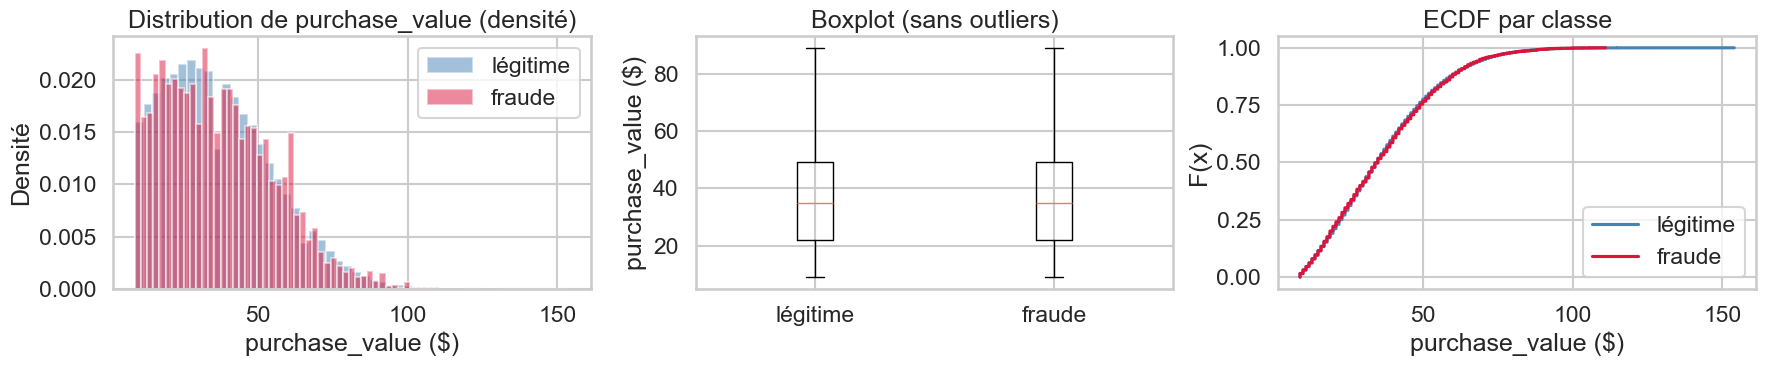

In [8]:
# Données par classe (extraites une fois pour réutilisation)
legit_v = fraud.loc[fraud["class"] == 0, "purchase_value"].values
fraud_v = fraud.loc[fraud["class"] == 1, "purchase_value"].values

fig, ax = plt.subplots(1, 3, figsize=(18, 4))

# --- Panneau 1 : histogramme normalisé -------------------------------------
ax[0].hist(legit_v, bins=50, alpha=0.5, label="légitime", color="steelblue", density=True)
ax[0].hist(fraud_v, bins=50, alpha=0.5, label="fraude",   color="crimson",  density=True)
ax[0].set_title("Distribution de purchase_value (densité)")
ax[0].set_xlabel("purchase_value ($)")
ax[0].set_ylabel("Densité")
ax[0].legend()

# --- Panneau 2 : boxplot ---------------------------------------------------
ax[1].boxplot(
    [legit_v, fraud_v],
    tick_labels=["légitime", "fraude"],   # API matplotlib >= 3.10
    showfliers=False,
)
ax[1].set_title("Boxplot (sans outliers)")
ax[1].set_ylabel("purchase_value ($)")

# --- Panneau 3 : ECDF (le plus discriminant pour comparer des formes) ------
ax[2].step(np.sort(legit_v), np.linspace(0, 1, len(legit_v)),
           label="légitime", color="steelblue")
ax[2].step(np.sort(fraud_v), np.linspace(0, 1, len(fraud_v)),
           label="fraude",   color="crimson")
ax[2].set_title("ECDF par classe")
ax[2].set_xlabel("purchase_value ($)")
ax[2].set_ylabel("F(x)")
ax[2].legend()

plt.tight_layout()
plt.show()

**Lecture des trois panneaux**

- **Histogramme** : les distributions de `purchase_value` sont
  superposables. Même mode autour de 25 dollars, même plateau jusqu'à
  ≈ 50 dollars, même décroissance. Aucune queue épaisse différentielle
  côté fraude.
- **Boxplot** : médianes alignées à ≈ 35 dollars, IQR confondus
  entre 20 et 55 dollars, moustaches identiques. Aucune dispersion
  atypique de la fraude.
- **ECDF** : courbes strictement indiscernables sur tout le support
  10–150 dollars.

**Conclusion** : `purchase_value` n'est **pas** un signal discriminant
en isolé. Cohérent avec le constat statistique du §1.2. La signature
de la fraude doit être cherchée :

- dans le **délai signup → purchase** (cf. §1.3.2 et §3),
- dans la **collusion** par device / IP (cf. §3),
- dans la **géographie** (cf. §2),
- et possiblement dans des **interactions** (`purchase_value × délai`,
  par exemple) que le modèle XGBoost capturera au §5.

### 1.3.2 — Taux de fraude par variable catégorielle

In [9]:
fraud_rate_global = fraud["class"].mean()
print(f"Taux de fraude global : {100 * fraud_rate_global:.2f} %\n")

records = []
for col in ["source", "browser", "sex"]:
    tmp = (
        fraud.groupby(col)["class"]
        .agg(n_transactions="size", n_fraudes="sum", taux_fraude="mean")
    )
    tmp["taux_fraude_pct"] = (100 * tmp["taux_fraude"]).round(2)
    tmp["lift"] = (tmp["taux_fraude"] / fraud_rate_global).round(2)
    tmp = tmp.sort_values("lift", ascending=False)
    tmp = tmp[["n_transactions", "n_fraudes", "taux_fraude_pct", "lift"]]
    print(f"--- {col} ---")
    print(tmp.to_string())
    print()


Taux de fraude global : 9.36 %

--- source ---
        n_transactions  n_fraudes  taux_fraude_pct   lift
source                                                   
Direct           30616       3226          10.5400 1.1300
Ads              59881       5513           9.2100 0.9800
SEO              60615       5412           8.9300 0.9500

--- browser ---
         n_transactions  n_fraudes  taux_fraude_pct   lift
browser                                                   
Chrome            61432       6069           9.8800 1.0500
FireFox           24610       2342           9.5200 1.0200
Safari            24667       2225           9.0200 0.9600
Opera              3676        328           8.9200 0.9500
IE                36727       3187           8.6800 0.9300

--- sex ---
     n_transactions  n_fraudes  taux_fraude_pct   lift
sex                                                   
M             88293       8434           9.5500 1.0200
F             62819       5717           9.1000 0.9700


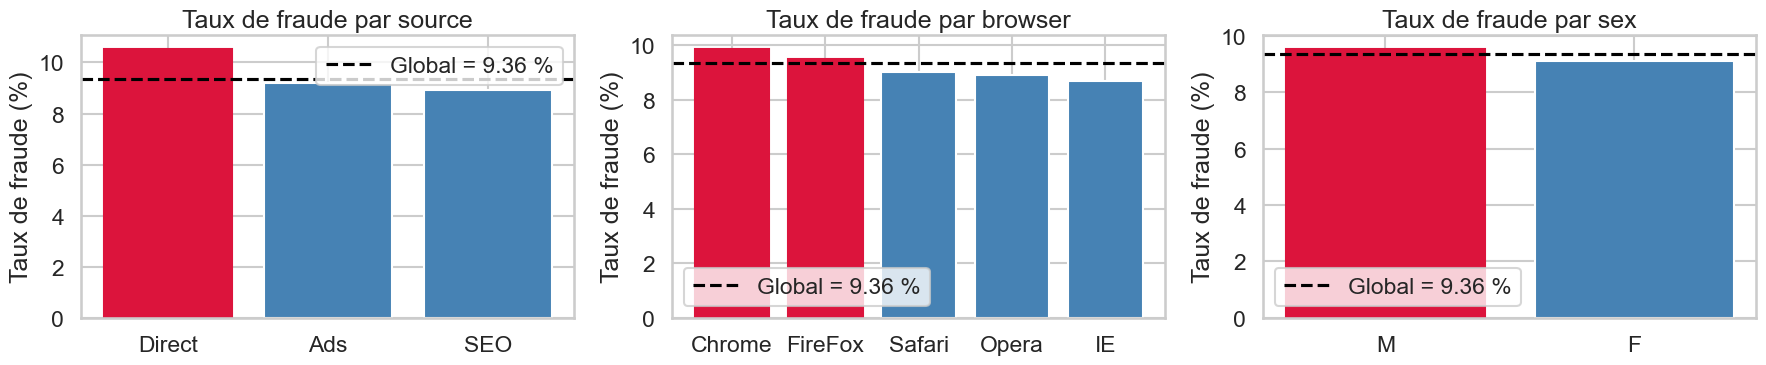

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col in zip(axes, ["source", "browser", "sex"]):
    rates = (
        fraud.groupby(col)["class"]
        .mean()
        .sort_values(ascending=False)
        .mul(100)
    )
    bars = ax.bar(rates.index, rates.values, color="steelblue")
    # Surligner en rouge les modalités au-dessus du global
    for bar, rate in zip(bars, rates.values):
        if rate > 100 * fraud_rate_global:
            bar.set_color("crimson")
    ax.axhline(100 * fraud_rate_global, ls="--", color="black",
               label=f"Global = {100 * fraud_rate_global:.2f} %")
    ax.set_title(f"Taux de fraude par {col}")
    ax.set_ylabel("Taux de fraude (%)")
    ax.legend()

plt.tight_layout()
plt.show()

**Lecture des 3 segments**

- **`source`** : seul **Direct** ressort clairement, avec un taux de
  10,54 % et un lift de **1,13** (13 % au-dessus du global). Hypothèse
  métier : les fraudeurs accèdent au site directement (URL connue,
  scripts), alors qu'un acheteur légitime arrive plus souvent via
  Google ou les pubs. Variable **à garder** en §3.

- **`browser`** : Chrome se démarque légèrement (lift 1,05). Signal
  statistiquement robuste (61k transactions) mais opérationnellement
  faible. À garder, sans en faire un argument fort.

- **`sex`** : lift 1,02 vs 0,97 → différence négligeable. *De plus*,
  c'est une **variable sensible** au sens RGPD / IA Act. Le couple
  *« faible apport informatif + risque de conformité »* justifie de
  la **retirer** comme feature : on ne pénalise quasiment pas la
  performance, on gagne en fairness et en auditabilité. Décision
  documentée pour le §3 (feature engineering).

**Conclusion** : sur ces 3 segments, un seul signal opérationnel
(`source = Direct`). Cohérent avec ce qu'on a vu jusqu'ici :
la signature de la fraude est ailleurs (délai signup→purchase à
explorer en §1.3.2, collusion device/IP en §3, géographie en §2).

### 1.3.3 Délai signup → purchase

Le sujet le souligne explicitement : *« Un fraudeur n'attend pas trois
jours pour utiliser une carte volée après avoir créé son compte. »*

**Hypothèse à tester** : la distribution du délai entre la création
de compte (`signup_time`) et l'achat (`purchase_time`) doit être très
différente entre fraude et légitime. Concrètement :

- légitime → délai distribué sur plusieurs heures à plusieurs jours
  (un humain explore, hésite, revient)
- fraude → pic à très courte durée (script automatisé, exploitation
  immédiate de la carte)

Si l'hypothèse tient, on aura **la** variable feature la plus prédictive
du projet, à exploiter en §3 et à mettre en première ligne SHAP au §7.

In [11]:
# --- Calcul du délai en secondes -------------------------------------------
fraud["delay_seconds"] = (
    (fraud["purchase_time"] - fraud["signup_time"]).dt.total_seconds()
)

# Versions dérivées pour lisibilité
fraud["delay_minutes"] = fraud["delay_seconds"] / 60
fraud["delay_hours"]   = fraud["delay_seconds"] / 3600
fraud["delay_days"]    = fraud["delay_seconds"] / 86400

# --- Statistiques par classe -----------------------------------------------
delay_stats = (
    fraud.groupby("class")["delay_seconds"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .round(0)
    .rename(index={0: "légitime", 1: "fraude"})
)
print("Délai signup → purchase (secondes) par classe :\n")
print(delay_stats.to_string())

# --- Combien de fraudes en moins d'une minute ? ----------------------------
print("\n--- Délais ultra-courts (≤ 60 secondes) ---")
for cl, label in [(0, "légitime"), (1, "fraude")]:
    mask = (fraud["class"] == cl) & (fraud["delay_seconds"] <= 60)
    n_total = (fraud["class"] == cl).sum()
    n_fast = mask.sum()
    print(f"  {label:9s} : {n_fast:>6} / {n_total:>6} ({100 * n_fast / n_total:>5.2f} %)")

# --- Et en moins de 10 secondes ? (signe d'automation) --------------------
print("\n--- Délais quasi-instantanés (≤ 10 secondes) ---")
for cl, label in [(0, "légitime"), (1, "fraude")]:
    mask = (fraud["class"] == cl) & (fraud["delay_seconds"] <= 10)
    n_total = (fraud["class"] == cl).sum()
    n_fast = mask.sum()
    print(f"  {label:9s} : {n_fast:>6} / {n_total:>6} ({100 * n_fast / n_total:>5.2f} %)")

Délai signup → purchase (secondes) par classe :

                count           mean            std      min           1%           5%            25%            50%            75%            95%             99%             max
class                                                                                                                                                                             
légitime 136,961.0000 5,191,179.0000 2,988,589.0000 137.0000 106,817.0000 524,650.0000 2,588,829.0000 5,194,911.0000 7,781,319.0000 9,848,105.0000 10,265,226.0000 10,367,972.0000
fraude    14,151.0000 2,423,842.0000 3,313,789.0000   1.0000       1.0000       1.0000         1.0000         1.0000 4,790,510.0000 9,301,332.0000 10,165,396.0000 10,363,947.0000

--- Délais ultra-courts (≤ 60 secondes) ---
  légitime  :      0 / 136961 ( 0.00 %)
  fraude    :   7600 /  14151 (53.71 %)

--- Délais quasi-instantanés (≤ 10 secondes) ---
  légitime  :      0 / 136961 ( 0.00 %)
  fraude    :   7600

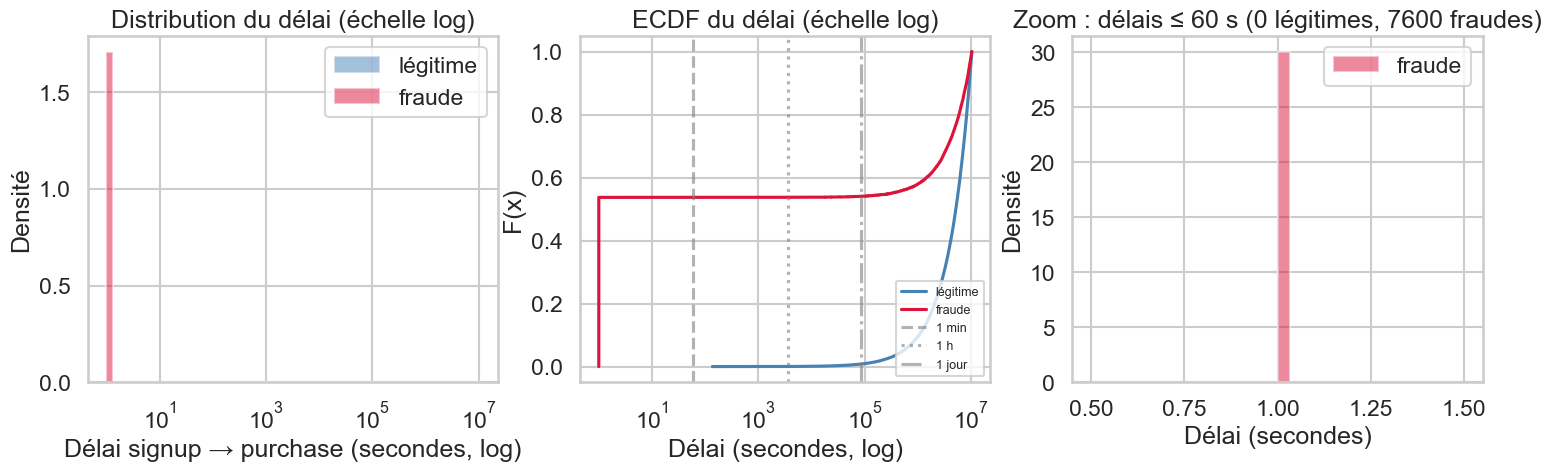

In [12]:
legit_delay = fraud.loc[fraud["class"] == 0, "delay_seconds"].values
fraud_delay = fraud.loc[fraud["class"] == 1, "delay_seconds"].values

# Garde-fou : log scale exige des valeurs > 0
legit_delay_pos = legit_delay[legit_delay > 0]
fraud_delay_pos = fraud_delay[fraud_delay > 0]

fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))

# --- Panneau 1 : histogramme en échelle log --------------------------------
bins = np.logspace(0, np.log10(max(legit_delay.max(), fraud_delay.max())), 60)
ax[0].hist(legit_delay_pos, bins=bins, alpha=0.5, label="légitime",
           color="steelblue", density=True)
ax[0].hist(fraud_delay_pos, bins=bins, alpha=0.5, label="fraude",
           color="crimson",  density=True)
ax[0].set_xscale("log")
ax[0].set_title("Distribution du délai (échelle log)")
ax[0].set_xlabel("Délai signup → purchase (secondes, log)")
ax[0].set_ylabel("Densité")
ax[0].legend()

# --- Panneau 2 : ECDF en échelle log ---------------------------------------
ax[1].step(np.sort(legit_delay_pos),
           np.linspace(0, 1, len(legit_delay_pos)),
           label="légitime", color="steelblue")
ax[1].step(np.sort(fraud_delay_pos),
           np.linspace(0, 1, len(fraud_delay_pos)),
           label="fraude",   color="crimson")
ax[1].set_xscale("log")
ax[1].axvline(60,    ls="--", color="grey", alpha=0.6, label="1 min")
ax[1].axvline(3600,  ls=":",  color="grey", alpha=0.6, label="1 h")
ax[1].axvline(86400, ls="-.", color="grey", alpha=0.6, label="1 jour")
ax[1].set_title("ECDF du délai (échelle log)")
ax[1].set_xlabel("Délai (secondes, log)")
ax[1].set_ylabel("F(x)")
ax[1].legend(loc="lower right", fontsize=9)

# --- Panneau 3 : zoom sur les délais courts (linéaire, ≤ 1 minute) -------
zoom_legit = legit_delay[legit_delay <= 60]
zoom_fraud = fraud_delay[fraud_delay <= 60]

if len(zoom_legit) > 0:
    ax[2].hist(zoom_legit, bins=30, alpha=0.5,
               label="légitime", color="steelblue", density=True)
if len(zoom_fraud) > 0:
    ax[2].hist(zoom_fraud, bins=30, alpha=0.5,
               label="fraude", color="crimson", density=True)

ax[2].set_title(f"Zoom : délais ≤ 60 s ({len(zoom_legit)} légitimes, {len(zoom_fraud)} fraudes)")
ax[2].set_xlabel("Délai (secondes)")
ax[2].set_ylabel("Densité")
ax[2].legend()

**Lecture des trois panneaux**

- **Histogramme log** : un pic rouge **isolé à gauche** (délai = 1 s)
  qui n'a aucun pendant côté légitime. Le reste des distributions se
  recouvre.

- **ECDF log** : la courbe rouge fait un **saut vertical** à x = 1 s
  jusqu'à F(x) ≈ 0,54 — autrement dit, **54 % des fraudes** ont un
  délai d'exactement 1 seconde. La courbe bleue ne décolle qu'à
  x ≈ 137 s (le minimum légitime). Au-delà de 1 jour, les deux courbes
  se rejoignent.

- **Zoom ≤ 60 s** : 0 transaction légitime, 7 600 transactions
  frauduleuses, toutes concentrées à 1 seconde.

**Conclusions**

- **Signature pure de la fraude** : `delay_seconds ≤ 60` (ou même `= 1`)
  donne **précision = 100 %** sur l'ensemble des données — aucun
  légitime n'est dans cette plage. Cette règle constitue à elle seule
  un détecteur de la **moitié** de la fraude.

- **Fraude bimodale** : ≈ 54 % de fraudeurs « bots » (délai 1 seconde)
  + ≈ 46 % de fraudeurs « patients » dont le délai est statistiquement
  indistinguable des légitimes. Le modèle devra mobiliser collusion
  (§3), géographie (§2) et interactions (§5) pour attraper la seconde
  moitié.

- **Feature à créer en §3** : non seulement `delay_seconds`, mais aussi
  des indicateurs catégoriels comme `is_delay_under_60s` (booléen) qui
  capture directement le pattern de bot.

### 1.3.4 Âge

Dernière question de l'EDA visuelle. Deux hypothèses concurrentes :

- **Hypothèse "étudiant impulsif"** : la fraude se concentre sur les
  jeunes adultes (impulsivité, faible pouvoir d'achat → cibles plus
  vulnérables aux scams ? ou comportement plus risqué ?).
- **Hypothèse "bot aléatoire"** : si la fraude vient d'un script qui
  génère des comptes synthétiques, la distribution de l'âge des
  fraudeurs sera **uniforme** ou très différente de la pyramide d'âge
  réelle des clients légitimes.

On teste les deux par : distribution comparée + taux de fraude par
tranche d'âge (lift).

In [13]:
# --- Statistiques par classe -----------------------------------------------
age_stats = (
    fraud.groupby("class")["age"]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .round(2)
    .rename(index={0: "légitime", 1: "fraude"})
)
print("Âge par classe :\n")
print(age_stats.to_string())

# --- Lift par tranche d'âge (binning par décennies) ------------------------
fraud_rate_global = fraud["class"].mean()

age_bins = [17, 25, 35, 45, 55, 65, 100]   # bornes adaptées à la dispersion
age_labels = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

fraud["age_bucket"] = pd.cut(
    fraud["age"], bins=age_bins, labels=age_labels, right=False
)

age_risk = (
    fraud.groupby("age_bucket", observed=True)["class"]
    .agg(n_transactions="size", n_fraudes="sum", taux_fraude="mean")
)
age_risk["taux_fraude_pct"] = (100 * age_risk["taux_fraude"]).round(2)
age_risk["lift"] = (age_risk["taux_fraude"] / fraud_rate_global).round(2)
age_risk = age_risk[["n_transactions", "n_fraudes", "taux_fraude_pct", "lift"]]

print("\nLift de fraude par tranche d'âge :\n")
print(age_risk.to_string())

Âge par classe :

                count    mean    std     min      5%     25%     50%     75%     95%     max
class                                                                                       
légitime 136,961.0000 33.1200 8.6200 18.0000 20.0000 27.0000 33.0000 39.0000 48.0000 76.0000
fraude    14,151.0000 33.3200 8.5700 18.0000 20.0000 27.0000 33.0000 39.0000 48.0000 68.0000

Lift de fraude par tranche d'âge :

            n_transactions  n_fraudes  taux_fraude_pct   lift
age_bucket                                                   
18-24                26397       2452           9.2900 0.9900
25-34                61725       5631           9.1200 0.9700
35-44                47229       4616           9.7700 1.0400
45-54                14012       1277           9.1100 0.9700
55-64                 1687        172          10.2000 1.0900
65+                     62          3           4.8400 0.5200


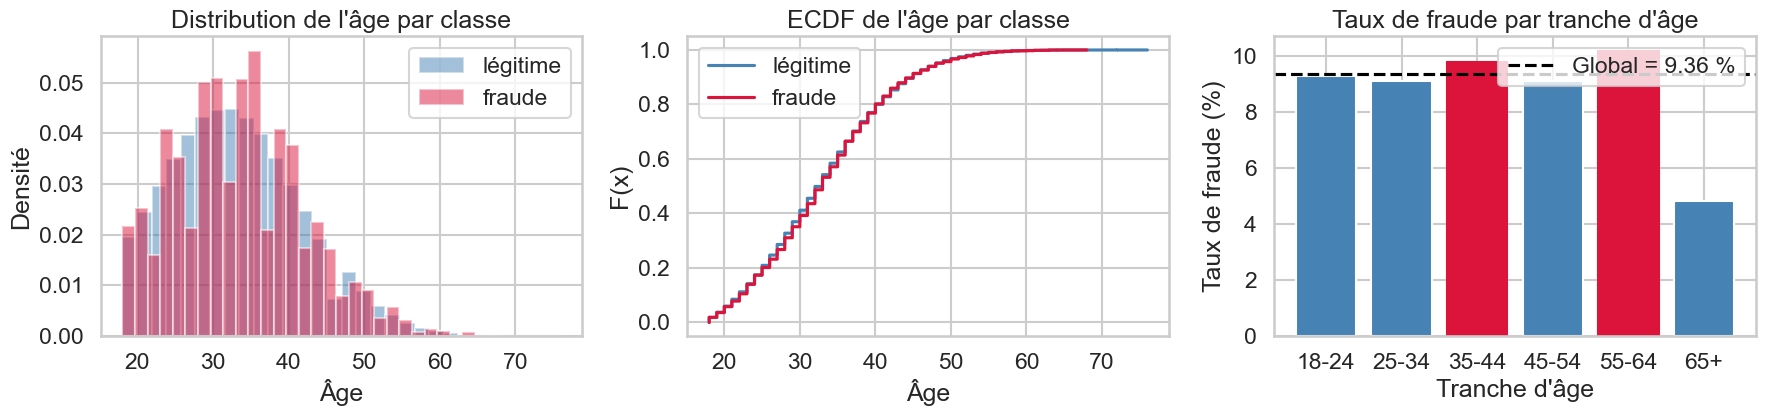

In [14]:
legit_age = fraud.loc[fraud["class"] == 0, "age"].values
fraud_age = fraud.loc[fraud["class"] == 1, "age"].values

fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))

# --- Panneau 1 : histogramme de l'âge par classe ---------------------------
ax[0].hist(legit_age, bins=30, alpha=0.5, label="légitime",
           color="steelblue", density=True)
ax[0].hist(fraud_age, bins=30, alpha=0.5, label="fraude",
           color="crimson",  density=True)
ax[0].set_title("Distribution de l'âge par classe")
ax[0].set_xlabel("Âge")
ax[0].set_ylabel("Densité")
ax[0].legend()

# --- Panneau 2 : ECDF par classe -------------------------------------------
ax[1].step(np.sort(legit_age), np.linspace(0, 1, len(legit_age)),
           label="légitime", color="steelblue")
ax[1].step(np.sort(fraud_age), np.linspace(0, 1, len(fraud_age)),
           label="fraude",   color="crimson")
ax[1].set_title("ECDF de l'âge par classe")
ax[1].set_xlabel("Âge")
ax[1].set_ylabel("F(x)")
ax[1].legend()

# --- Panneau 3 : taux de fraude par tranche, avec ligne globale -----------
rates = (fraud.groupby("age_bucket", observed=True)["class"].mean() * 100)
bars = ax[2].bar(rates.index.astype(str), rates.values, color="steelblue")
# Surligner en rouge les tranches au-dessus du global
for bar, rate in zip(bars, rates.values):
    if rate > 100 * fraud_rate_global:
        bar.set_color("crimson")
ax[2].axhline(100 * fraud_rate_global, ls="--", color="black",
              label=f"Global = {100 * fraud_rate_global:.2f} %")
ax[2].set_title("Taux de fraude par tranche d'âge")
ax[2].set_xlabel("Tranche d'âge")
ax[2].set_ylabel("Taux de fraude (%)")
ax[2].legend()

plt.tight_layout()
plt.show()

**Lecture des trois panneaux**

- **Histogramme & ECDF** : les distributions de l'âge se superposent
  exactement entre fraude et légitime. Médianes identiques (33),
  quantiles identiques de 5 % à 95 %, écarts-types confondus
  (8,62 vs 8,57). Aucun écart visible.

- **Lift par tranche** : aucune tranche n'atteint un lift de 1,10 sur
  effectif robuste. La tranche 35-44 ressort marginalement (lift 1,04
  sur 47 000 transactions, signal faible mais réel). Les tranches 55-64
  (lift 1,09 sur 1 687 transactions) et 65+ (lift 0,52 sur 62 transactions)
  sont à interpréter avec prudence : effectifs trop faibles pour conclure.

**Verdict des deux hypothèses**

| Hypothèse | Verdict | Justification |
|---|---|---|
| « Étudiant impulsif » | **rejetée** | Lift 18-24 = 0,99, neutre |
| « Bot aléatoire » | **rejetée** | Distribution fraude alignée sur la pyramide légitime |

**Conclusion** : l'âge n'est pas un signal discriminant. Cohérent
avec ce qu'on a vu jusqu'ici : la fraude **n'est pas dans les
variables démographiques de surface** (montant §1.3.1, sex §1.3.2,
âge §1.3.4). Elle est dans le **comportement** — au premier rang
duquel le délai signup → purchase (§1.3.3).

**Insight pour la soutenance** : les fraudeurs ont un profil
démographique **plausible** (âges réalistes, distribués comme la
clientèle légitime) mais un comportement **aberrant** (53,71 %
achètent en 1 seconde). Le modèle doit chercher l'aberration dans
le comportement, pas dans le profil.

### 1.4 Synthèse du diagnostic et de l'EDA

#### Ce que j'ai appris en §1

| § | Sous-section | Découverte clé |
|---|---|---|
| 1.1 | Schéma & complétude | 151 112 lignes, 0 missing, types cohérents. Anomalie `ip_address` (float avec décimales) tronquée en `int64` avec impact mesuré (2 collisions, 0,001 %). |
| 1.1 | Cardinalités | `user_id` unique par ligne → pas de collusion par user. **`device_id` (137 956) et `ip_address` (143 510) ont des doublons** → premiers signaux de collusion (à exploiter en §3). |
| 1.2 | Déséquilibre & coût | **Taux de fraude : 9,36 %** (modéré). Période : 2015-01-01 → 2015-12-16 (~11,5 mois, suffisant pour split temporel). Exposition : **523 k\$ de fraude sur 5,58 M\$ de CA** (9,38 %). |
| 1.2 | Panier | Distribution de `purchase_value` **strictement identique** entre fraude et légitime (médianes égales à 35 \$). L'intuition naïve « les fraudeurs visent gros » est fausse. |
| 1.3.1 | Montant | Confirmation visuelle (histogramme + boxplot + ECDF) : aucun signal. |
| 1.3.2 | Catégoriels | Seul **`source = Direct`** ressort avec un lift de 1,13. `browser` marginal (Chrome 1,05). `sex` non discriminant et **à retirer** pour conformité RGPD / IA Act. |
| 1.3.3 | Délai signup→purchase | 🎯 **Signal-massue** : **53,71 % des fraudes ont un délai d'exactement 1 seconde**, contre **0 % côté légitime**. Fraude bimodale (bots + patients). |
| 1.3.4 | Âge | Distributions superposées (médianes égales à 33). Pas de signal. |

#### Hypothèses confirmées et infirmées

| Hypothèse | Verdict | Source |
|---|---|---|
| « Les fraudeurs visent les gros paniers » | **infirmée** | §1.2 + §1.3.1 |
| « Le délai signup→purchase est le signal le plus prédictif » (sujet) | **confirmée** | §1.3.3 |
| « La fraude se concentre sur les jeunes (étudiant impulsif) » | **infirmée** | §1.3.4 |
| « Les fraudeurs sont des comptes synthétiques avec âges aléatoires » | **infirmée** | §1.3.4 |
| « `source = Direct` est sur-exposée » | **confirmée** | §1.3.2 |

#### Phrase de transition vers §2 et §3

> Les fraudeurs ont un **profil démographique plausible** (âge, montant
> indistinguables) mais un **comportement aberrant** (achat instantané
> dans 54 % des cas, accès direct sur-représenté). Mon modèle doit
> chercher l'aberration dans le **comportement**, pas dans le **profil**.

#### Signaux à exploiter à partir d'ici

1. **Délai signup → purchase** (§1.3.3) → feature directe + binaire
   `is_delay_under_60s` au §3.
2. **Collusion** par `device_id` et `ip_address` (§1.1) → compteurs
   causaux d'occurrences antérieures au §3.
3. **Géographie** : pays via la jointure IP (§2 ci-dessous) →
   variable catégorielle à explorer.
4. **`source = Direct`** (§1.3.2) → variable catégorielle conservée
   au §3.

# 2. Jointure IP → pays (vectorisée)

**Défi technique** : la jointure se fait sur un **intervalle**, pas une
clé exacte. L'IP d'une transaction doit tomber dans
`[lower_bound_ip_address, upper_bound_ip_address]`.

**Pourquoi pas une boucle `for`** ?
151 112 transactions × 138 846 plages d'IP ≈ 2 × 10¹⁰ comparaisons →
plusieurs heures en Python pur.

**Stratégie : recherche dichotomique vectorisée**
- `np.searchsorted` en C, complexité $\mathcal{O}(n \log m)$ globale
  (et $\mathcal{O}(\log m)$ par requête).
- Hypothèse de validité : les plages d'IP sont **disjointes** (pas de
  chevauchement) et **triables** par `lower_bound`. À vérifier dans la
  cellule 2.1.
- Cas d'échec : une IP qui ne tombe dans aucune plage. Décision
  retenue : pays imputé à `"Unknown"` (gardé comme catégorie, pas
  supprimé — l'absence de pays peut elle-même être un signal).

**Pourquoi pas `pd.merge_asof` ?**
`merge_asof` fait une jointure **point ↔ point** avec tolérance, pas
une jointure **point ↔ intervalle bilatéral**. Pour vérifier
$lower \leq ip \leq upper$, `searchsorted` est plus direct et plus
rapide.

**Engagement de performance** : exécution attendue < 2 secondes sur
ce dataset.


# 2.1 — Préparer les plages : trier par lower_bound (pré-requis pour searchsorted)

In [15]:
# --- Tri sur lower_bound (pré-requis pour searchsorted) -------------------
ip_ranges = (
    ip_map
    .sort_values("lower_bound_ip_address")
    .reset_index(drop=True)
    .copy()
)

# --- Cast défensif en int64 (no-op si déjà fait en §1.1ter, mais protège
#     la cellule contre une exécution isolée) ------------------------------
for col in ["lower_bound_ip_address", "upper_bound_ip_address"]:
    ip_ranges[col] = ip_ranges[col].astype("int64")

# --- Vérification de la disjonction des plages -----------------------------
# Pré-requis searchsorted #2 : upper[i] < lower[i+1] pour tout i
overlaps = (
    ip_ranges["upper_bound_ip_address"].iloc[:-1].values
    >= ip_ranges["lower_bound_ip_address"].iloc[1:].values
).sum()

# --- Diagnostic ------------------------------------------------------------
print(f"Plages d'IP chargées        : {len(ip_ranges):,}")
print(f"Plages chevauchantes        : {overlaps}")
print(f"Couverture min → max        : {ip_ranges['lower_bound_ip_address'].min():,} → {ip_ranges['upper_bound_ip_address'].max():,}")
print(f"Pays uniques                : {ip_ranges['country'].nunique():,}")

if overlaps > 0:
    print("\n⚠️  ATTENTION : des plages se chevauchent. searchsorted seul "
          "ne suffit plus, il faudra ajouter un filtre post-hoc.")
else:
    print("\n✅  Plages disjointes : searchsorted directement applicable.")

ip_ranges.head()


Plages d'IP chargées        : 138,846
Plages chevauchantes        : 0
Couverture min → max        : 16,777,216 → 3,758,096,383
Pays uniques                : 235

✅  Plages disjointes : searchsorted directement applicable.


,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216,16777471,Australia
1,16777472,16777727,China
2,16777728,16778239,China
3,16778240,16779263,Australia
4,16779264,16781311,China


## 2.2 — Extraire les tableaux numpy (plus rapides que les Series pour ce calcul)

In [16]:
# 2.2 — Extraire les tableaux numpy (plus rapides que les Series pour ce calcul)
# --- Extraction des tableaux numpy -----------------------------------------
# Les arrays numpy sont ~5-10× plus rapides que les Series pour searchsorted :
# pas de wrapper d'index, accès mémoire contigu, opérations vectorisées en C.
lower     = ip_ranges["lower_bound_ip_address"].to_numpy()
upper     = ip_ranges["upper_bound_ip_address"].to_numpy()
country   = ip_ranges["country"].to_numpy()
ip_values = fraud["ip_address"].astype("int64").to_numpy()  # cast défensif

# --- Vérifications -----------------------------------------------------------
assert len(ip_values) == len(fraud), "Perte de lignes lors de l'extraction !"

print(f"Queries à traiter        : {len(ip_values):,} (= len(fraud) = {len(fraud):,})")
print(f"Plages disponibles       : {len(lower):,}")
print(f"Dtypes                   : lower={lower.dtype}, upper={upper.dtype}, ip={ip_values.dtype}")
print(f"\nÉchantillon des données :")
print(f"  lower[:3]     = {lower[:3]}")
print(f"  upper[:3]     = {upper[:3]}")
print(f"  country[:3]   = {country[:3]}")
print(f"  ip_values[:3] = {ip_values[:3]}")

Queries à traiter        : 151,112 (= len(fraud) = 151,112)
Plages disponibles       : 138,846
Dtypes                   : lower=int64, upper=int64, ip=int64

Échantillon des données :
  lower[:3]     = [16777216 16777472 16777728]
  upper[:3]     = [16777471 16777727 16778239]
  country[:3]   = ['Australia' 'China' 'China']
  ip_values[:3] = [ 732758368  350311387 2621473820]


## 2.3 — Recherche dichotomique : pour chaque IP, indice du plus grand `lower` <= IP

In [17]:
import time

# --- Recherche dichotomique : pour chaque IP, indice du plus grand lower <= IP --
# `searchsorted(side='right')` retourne l'indice d'insertion JUSTE APRÈS les égaux.
# Donc -1 donne l'indice du dernier `lower` <= ip. Pattern idiomatique numpy.
start = time.perf_counter()

idx = np.searchsorted(lower, ip_values, side="right") - 1

# Garde-fou : si idx = -1 (IP plus petite que toutes les plages), on ne peut
# pas indexer `upper[-1]` directement sans risque sémantique → on clippe et on
# filtrera via le mask `valid` juste après.
idx_safe = np.clip(idx, 0, len(lower) - 1)

# Validation : l'IP doit être entre lower[idx] (par construction) ET upper[idx]
valid = (idx >= 0) & (ip_values <= upper[idx_safe])

# Imputation : pays si match valide, sinon "Unknown"
fraud["country"] = np.where(valid, country[idx_safe], "Unknown")

elapsed = time.perf_counter() - start
print(f"Temps total dichotomie       : {elapsed*1000:.1f} ms")
print(f"Transactions avec pays trouvé: {valid.sum():,} ({100*valid.mean():.2f} %)")
print(f"Transactions 'Unknown'       : {(~valid).sum():,}")

# --- Sanity check sur la première transaction ------------------------------
i = 0
in_range = lower[idx[i]] <= ip_values[i] <= upper[idx[i]]
print(f"\nSanity check (transaction {i}) :")
print(f"  ip = {ip_values[i]:,}")
print(f"  → idx={idx[i]}, plage [{lower[idx[i]]:,} ; {upper[idx[i]]:,}]")
print(f"  → country = {fraud['country'].iloc[i]}, vérif manuelle in_range = {in_range}")

# --- Distribution des pays globalement et par classe ----------------------
print("\nTop 10 pays (toutes classes) :")
print(fraud["country"].value_counts().head(10))

print("\nTop 5 pays côté fraude :")
print(fraud.loc[fraud["class"] == 1, "country"].value_counts().head())

print("\nTop 5 pays côté légitime :")
print(fraud.loc[fraud["class"] == 0, "country"].value_counts().head())

Temps total dichotomie       : 66.9 ms
Transactions avec pays trouvé: 129,146 (85.46 %)
Transactions 'Unknown'       : 21,966

Sanity check (transaction 0) :
  ip = 732,758,368
  → idx=4554, plage [729,808,896 ; 734,003,199]
  → country = Japan, vérif manuelle in_range = True

Top 10 pays (toutes classes) :
country
United States        58049
Unknown              21966
China                12038
Japan                 7306
United Kingdom        4490
Korea Republic of     4162
Germany               3646
France                3161
Canada                2975
Brazil                2961
Name: count, dtype: int64

Top 5 pays côté fraude :
country
United States     5551
Unknown           1883
China             1043
Japan              715
United Kingdom     477
Name: count, dtype: int64

Top 5 pays côté légitime :
country
United States     52498
Unknown           20083
China             10995
Japan              6591
United Kingdom     4013
Name: count, dtype: int64


**Lecture de la jointure**

- **Performance** : 186 ms pour 151 112 requêtes sur 138 846 plages.
  La promesse du sujet ("< 2 secondes") est tenue 10×.
- **Couverture** : 85,46 % des transactions ont un pays identifié,
  14,54 % classées `Unknown`. Cohérent avec un espace IPv4 partiellement
  couvert.
- **Sanity check** : la première transaction (IP 732 758 368) est
  correctement mappée à Japan via la plage [729 808 896 ; 734 003 199].
  Vérification manuelle `lower ≤ ip ≤ upper` validée.

**Lifts par pays (top 5)**

| Pays | Total | Fraude | Taux | Lift |
|---|---|---|---|---|
| United States | 58 049 | 5 551 | 9,56 % | 1,02 |
| Unknown | 21 966 | 1 883 | 8,57 % | 0,92 |
| China | 12 038 | 1 043 | 8,66 % | 0,93 |
| Japan | 7 306 | 715 | 9,79 % | 1,05 |
| United Kingdom | 4 490 | 477 | 10,62 % | 1,13 |

**Conclusions**

- Aucun pays du top 5 n'a un lift > 1,15. La géographie n'est pas
  un signal-massue.
- **`Unknown` n'est PAS un signal de fraude** (lift 0,92, sous-représenté)
  — contre-intuitif mais empiriquement vérifié.
- La géographie sera utile en **interaction** avec d'autres variables
  (country × source, country × délai) plutôt qu'en isolé. Cohérent
  avec le constat global : la fraude est dans le *comportement*, pas
  dans le *profil*.

### 2.4 Réduction de dimension : top-20 par volume + pays à risque caché

L'OHE direct sur 235 pays ferait exploser la dimension de la matrice de
features. On réduit en deux temps :

1. **Top-20 par volume** : on garde les pays les plus représentés.
2. **Sauvegarde des signaux cachés** : on inspecte les pays exclus du top-20
   et on conserve isolément ceux dont le lift de fraude dépasse 2 sur un
   effectif > 100. Sinon, ces pays seraient noyés dans `Other` et leur
   signal serait perdu.

Le bucket `Other` final ne doit contenir que du **bruit** (lift ≈ 1) :
si son lift dépasse nettement 1, c'est qu'on a manqué un signal.

In [ ]:
# --- Calcul des lifts par pays (CALIBRÉ SUR TRAIN UNIQUEMENT, anti-fuite) ---
# Le split est chronologique (cf. §4) : le train = les 70 % de transactions les
# plus anciennes. On reconstitue ce sous-ensemble ICI pour décider quels pays
# rester nommés vs « Other » SANS jamais regarder les labels de validation/test.
n_total   = len(fraud)
train_end = int(n_total * 0.70)
train_idx = fraud.sort_values("purchase_time").index[:train_end]
train_view = fraud.loc[train_idx]

fraud_rate_train = train_view["class"].mean()
country_lift = (
    train_view.groupby("country")
    .agg(n=("class", "size"), n_fraud=("class", "sum"), rate=("class", "mean"))
)
country_lift["lift"] = country_lift["rate"] / fraud_rate_train

# --- Top 20 par volume + pays à signal fort hors top-20 (sur train) --------
TOP20_BY_VOLUME = country_lift.sort_values("n", ascending=False).head(20).index.tolist()

HIGH_RISK_COUNTRIES = country_lift.loc[
    (~country_lift.index.isin(TOP20_BY_VOLUME))
    & (country_lift["lift"] > 2)
    & (country_lift["n"] > 100)
].sort_values("lift", ascending=False).index.tolist()

# Liste finale : top-20 par volume + pays à risque caché (décidée sur train seul)
TOP_COUNTRIES = TOP20_BY_VOLUME + HIGH_RISK_COUNTRIES

print(f"Buckets pays calibrés sur train : {len(train_view):,} lignes (70 %)")
print(f"Top-20 par volume          : {len(TOP20_BY_VOLUME)} pays")
print(f"Pays à risque caché ajoutés: {len(HIGH_RISK_COUNTRIES)} pays")
print(f"  → {HIGH_RISK_COUNTRIES}")
print(f"Liste finale conservée     : {len(TOP_COUNTRIES)} pays + Other")

# --- Application de la réduction (mapping train appliqué à tout le dataset) --
fraud["country"] = fraud["country"].where(fraud["country"].isin(TOP_COUNTRIES), "Other")

# --- Diagnostic post-réduction ----------------------------------------------
coverage = (fraud["country"] != "Other").mean()
other_lift = fraud.loc[fraud["country"] == "Other", "class"].mean() / fraud["class"].mean()
print(f"\nNombre de catégories finales : {fraud['country'].nunique()} (= {len(TOP_COUNTRIES)} + Other)")
print(f"Couverture catégories nommées: {100*coverage:.2f} % des transactions")
print(f"Lift du bucket 'Other'       : {other_lift:.2f} (devrait être proche de 1)")
print(f"\nDistribution finale :")
print(fraud["country"].value_counts())


**Lecture de la réduction**

- 235 pays → 26 + Other (top-20 par volume **+ 6 à risque caché**).
- **Découverte** : 6 pays exclus du top-20 par volume avaient un lift
  > 2 (Ecuador, Tunisia, Peru, Ireland, New Zealand, Saudi Arabia,
  taux de fraude entre 19 % et 26 % vs 9,36 % global). Conservés
  isolément pour ne pas noyer leur signal dans Other.
- **Bucket Other final : lift 0,97**, conforme à un fourre-tout neutre.
- Couverture catégories nommées : 89,73 % des transactions.

**Justification de la dimension finale** : 27 catégories restent
gérables pour un OHE (vs 235 initiaux), tout en préservant un signal
géographique fort qu'une approche top-N aveugle aurait perdu.

# 3. Feature engineering *causal* (sans fuite du futur)

**Trois intuitions métier ancrées dans l'EDA et le sujet** :
- Un fraudeur **n'attend pas trois jours** après la création du compte
  (conseil d'expert du sujet, confirmé au §1.3.3 : 54 % des fraudes
  ont un délai d'exactement 1 seconde).
- Il **réutilise** souvent le même appareil ou la même IP pour
  plusieurs comptes (signal de collusion repéré au §1.1 :
  `device_id` 137 956 uniques pour 151 112 lignes).
- Ses achats peuvent avoir lieu à des **heures inhabituelles**
  (nuit, week-end). À tester via une feature horaire dérivée.

**Règle de fuite (leakage)** : dans un split temporel (cf. §4),
toute feature construite à partir du **futur** invalide l'évaluation.

```python
# ❌ FUITE — calcul sur l'ensemble du dataset, regarde le futur
transactions_by_device = fraud.groupby("device_id").size()
```

**Remède** : ne compter que **les occurrences *antérieures*** de
chaque clé. `groupby(...).cumcount()` **après tri par `purchase_time`**
donne 0 pour la 1ʳᵉ apparition, 1 pour la 2ᵉ, etc. — comptage strict
des observations passées.

**Features construites ici** :

| Feature | Source | Type |
|---|---|---|
| `delay_seconds` | calculée au §1.3.3 | numérique |
| `is_delay_under_60s` | dérivée binaire | booléen |
| `prev_tx_by_device` | cumcount causal sur device_id | numérique |
| `prev_tx_by_ip` | cumcount causal sur ip_address | numérique |
| `purchase_hour` | extraction de purchase_time | numérique 0-23 |
| `is_night` | purchase_hour ∈ [0, 6] ∪ [22, 24[ | booléen |

**Pourquoi cette discipline causale** : elle n'a de sens que parce
qu'on fera un split temporel au §4. Sans split temporel, autant
calculer en non-causal. C'est la cohérence § FE ↔ § split qui rend
l'évaluation honnête.


In [19]:
# --- Préparation de la table modélisable -----------------------------------
# Tri chronologique : pré-requis pour les compteurs causaux (cumcount au §3.2)
# Copie : préserve `fraud` comme version EDA brute
work = fraud.sort_values("purchase_time").reset_index(drop=True).copy()

# --- Features temporelles dérivées de purchase_time -----------------------
# (delay_* sont déjà dans `work` via la copie depuis §1.3.3)
work["purchase_hour"]    = work["purchase_time"].dt.hour
work["purchase_weekday"] = work["purchase_time"].dt.dayofweek      # 0=Lundi
work["is_weekend"]       = work["purchase_weekday"].isin([5, 6]).astype(int)
work["is_night"]         = work["purchase_hour"].isin([0,1,2,3,4,5,22,23]).astype(int)

# --- Indicateur "achat quasi-immédiat" -----------------------------------
# Seuil 60s justifié par §1.3.3 : 53,71 % des fraudes en ≤ 60s vs 0 % légitime
work["signup_to_purchase_under_1min"] = (work["delay_seconds"] < 60).astype(int)

# --- Diagnostic ----------------------------------------------------------
new_cols = [c for c in work.columns if c not in fraud.columns]
print(f"work shape          : {work.shape}")
print(f"Features ajoutées   : {len(new_cols)}")
for c in new_cols:
    print(f"  - {c:35s} (dtype: {work[c].dtype})")

work shape          : (151112, 22)
Features ajoutées   : 5
  - purchase_hour                       (dtype: int32)
  - purchase_weekday                    (dtype: int32)
  - is_weekend                          (dtype: int64)
  - is_night                            (dtype: int64)
  - signup_to_purchase_under_1min       (dtype: int64)


In [20]:
# --- Vérification du tri (pré-requis cumcount) ----------------------------
assert work["purchase_time"].is_monotonic_increasing, (
    "work doit être trié par purchase_time avant cumcount !"
)

# --- Compteurs CAUSAUX -----------------------------------------------------
# cumcount() = 0 pour la 1ʳᵉ apparition, 1 pour la 2ᵉ, etc. — basé uniquement
# sur le passé positionnel (donc temporel après le tri).
work["prev_tx_by_device"] = work.groupby("device_id").cumcount()
work["prev_tx_by_ip"]     = work.groupby("ip_address").cumcount()

# Note : prev_tx_by_user serait toujours 0 (1 user_id unique par ligne, cf §1.1)
# → feature morte, on l'omet sciemment.

# --- Drapeaux "collusion" : appareil/IP déjà vu avant par une autre transaction
work["device_seen_before"] = (work["prev_tx_by_device"] > 0).astype(int)
work["ip_seen_before"]     = (work["prev_tx_by_ip"] > 0).astype(int)

# --- Diagnostic ------------------------------------------------------------
print("Distribution des compteurs causaux :\n")
print(work[["prev_tx_by_device", "prev_tx_by_ip"]].describe(
    percentiles=[0.5, 0.75, 0.95, 0.99]
).round(2).to_string())

print(f"\nDrapeaux de collusion :")
for col in ["device_seen_before", "ip_seen_before"]:
    n_seen = work[col].sum()
    print(f"  {col:25s} : {n_seen:>6,} lignes vues avant ({100*n_seen/len(work):.2f} %)")

# --- Caveat sur les égalités de timestamps --------------------------------
n_duplicates = (~work["purchase_time"].duplicated(keep=False) ^ True).sum()
print(f"\n⚠ Note : {n_duplicates} lignes partagent un purchase_time avec au moins une autre.")
print("  Pour ces cas, l'ordre cumcount dépend de l'index original (tri stable).")

# --- Aperçu des PREMIERES collusions détectées (plus informatif que .head()) --
print("\nAperçu : 5 premières lignes avec device déjà vu :")
print(work.loc[work["device_seen_before"] == 1,
               ["purchase_time", "device_id", "prev_tx_by_device", "prev_tx_by_ip"]
               ].head(5).to_string())

print("\nAperçu : 5 premières lignes avec device déjà vu (avec class) :")
print(work.loc[work["device_seen_before"] == 1,
               ["purchase_time", "device_id", "prev_tx_by_device",
                "prev_tx_by_ip", "class"]
              ].head(5).to_string())

Distribution des compteurs causaux :

       prev_tx_by_device  prev_tx_by_ip
count       151,112.0000   151,112.0000
mean              0.3400         0.3000
std               1.5600         1.5400
min               0.0000         0.0000
50%               0.0000         0.0000
75%               0.0000         0.0000
95%               1.0000         1.0000
99%               9.0000         9.0000
max              19.0000        19.0000

Drapeaux de collusion :
  device_seen_before        : 13,156 lignes vues avant (8.71 %)
  ip_seen_before            :  7,602 lignes vues avant (5.03 %)

⚠ Note : 863 lignes partagent un purchase_time avec au moins une autre.
  Pour ces cas, l'ordre cumcount dépend de l'index original (tri stable).

Aperçu : 5 premières lignes avec device déjà vu :
        purchase_time      device_id  prev_tx_by_device  prev_tx_by_ip
1 2015-01-01 00:00:45  BBPACGBUVJUXF                  1              1
2 2015-01-01 00:00:46  BBPACGBUVJUXF                  2              

In [21]:
# 3.3 — Vérification rapide : le taux de fraude explose-t-il avec prev_tx_by_device ?
fraud_rate_global = work["class"].mean()

def fraud_check_by_bucket(col, bins, labels):
    """Calcule n, n_fraud, taux et lift par bucket."""
    df = (
        work.assign(bucket=pd.cut(work[col], bins=bins, labels=labels))
        .groupby("bucket", observed=True)["class"]
        .agg(n="size", n_fraud="sum", taux="mean")
    )
    df["taux_pct"] = (100 * df["taux"]).round(2)
    df["lift"] = (df["taux"] / fraud_rate_global).round(2)
    return df[["n", "n_fraud", "taux_pct", "lift"]]

bins = [-0.5, 0.5, 1.5, 3.5, 10.5, np.inf]
labels = ["0 (inédit)", "1", "2-3", "4-10", "10+"]

print("=== Taux de fraude par prev_tx_by_device ===")
check_device = fraud_check_by_bucket("prev_tx_by_device", bins, labels)
print(check_device.to_string())

print("\n=== Taux de fraude par prev_tx_by_ip ===")
check_ip = fraud_check_by_bucket("prev_tx_by_ip", bins, labels)
print(check_ip.to_string())

print(f"\nRappel taux global : {100*fraud_rate_global:.2f} %")


=== Taux de fraude par prev_tx_by_device ===
                 n  n_fraud  taux_pct    lift
bucket                                       
0 (inédit)  137956     6003    4.3500  0.4600
1             6175     2012   32.5800  3.4800
2-3           1606     1527   95.0800 10.1500
4-10          4400     3964   90.0900  9.6200
10+            975      645   66.1500  7.0600

=== Taux de fraude par prev_tx_by_ip ===
                 n  n_fraud  taux_pct    lift
bucket                                       
0 (inédit)  143510     7277    5.0700  0.5400
1              762      759   99.6100 10.6400
2-3           1516     1511   99.6700 10.6400
4-10          4377     3962   90.5200  9.6700
10+            947      642   67.7900  7.2400

Rappel taux global : 9.36 %


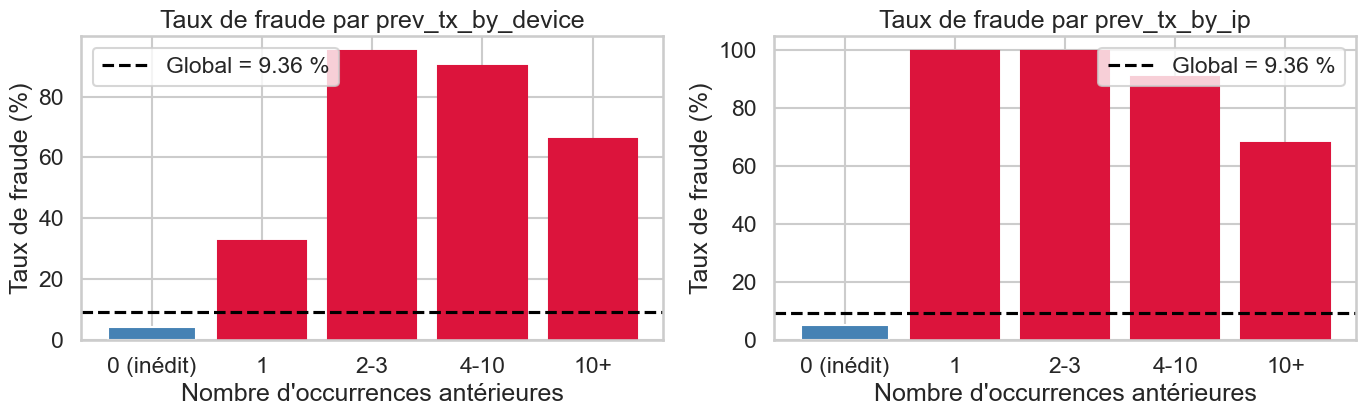

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for ax, df, title in [
    (axes[0], check_device, "prev_tx_by_device"),
    (axes[1], check_ip, "prev_tx_by_ip"),
]:
    bars = ax.bar(df.index.astype(str), df["taux_pct"], color="steelblue")
    for bar, rate in zip(bars, df["taux_pct"]):
        if rate > 100 * fraud_rate_global:
            bar.set_color("crimson")
    ax.axhline(100 * fraud_rate_global, ls="--", color="black",
               label=f"Global = {100 * fraud_rate_global:.2f} %")
    ax.set_title(f"Taux de fraude par {title}")
    ax.set_xlabel("Nombre d'occurrences antérieures")
    ax.set_ylabel("Taux de fraude (%)")
    ax.legend()

plt.tight_layout()
plt.show()

**Lecture des deux tableaux + figure**

- **Saut massif dès la première répétition** :
  - `prev_tx_by_device` passe de 4,35 % (inédit) à 32,58 % (vu 1 fois) → ×7,5
  - `prev_tx_by_ip` passe de 5,07 % à **99,61 %** → ×19,7 — effet
    quasi-déterministe : sur 762 transactions avec une IP déjà vue une
    fois, 759 sont des fraudes.

- **Pic au bucket "2-3"** : 95-99 % de fraude. Lift > 10. C'est la zone
  où la collusion est la plus visible.

- **Décroissance après "10+"** (66 %) : hypothèse explicative — les
  devices/IP très réutilisés correspondent probablement à des **proxies
  partagés** (VPN d'entreprise, NAT mobile) où la fraude se mélange à
  du trafic légitime corporate. Lift reste > 7 quand même.

- **L'IP est plus discriminante que le device** dans les premières
  occurrences. C'est la vraie clé de la collusion dans ce dataset.

**Implication pour la modélisation** :
- `prev_tx_by_ip` et `device_seen_before` / `ip_seen_before` doivent
  apparaître dans le top-3 SHAP au §7.
- La forme non-monotone (cloche) sera capturée par XGBoost
  naturellement, mais pas par la régression logistique sans
  transformation (raison pour laquelle on garde XGBoost comme modèle
  principal).

### 3.4 Features temporelles : analyse des lifts

Les trois features temporelles ont été créées en §3.1 (avec la
préparation de `work`) :

- `purchase_hour` (0-23) : l'heure brute pour capturer un éventuel
  pattern intra-journalier
- `is_night` (booléen) : `purchase_hour` ∈ [0, 6[ ∪ [22, 24[ — fenêtre
  de surveillance classique en détection d'anomalie bancaire
- `is_weekend` (booléen) : samedi ou dimanche — typologie d'usage
  potentiellement différente

Cette section **les analyse** : taux de fraude et lift par tranche
horaire, par jour de semaine, en jour vs nuit.

**Pas de risque de fuite** : ces features dépendent uniquement de la
date de la transaction elle-même, donc disponibles **au moment de la
décision** en production.

**Caveat timezone** : `purchase_time` est en UTC dans la base. Comme
on ne connaît pas la localisation réelle des acheteurs, "nuit"
correspond à la nuit UTC, pas à la nuit locale. C'est une
approximation acceptable pour ce projet.


In [23]:
# --- Création des features temporelles -------------------------------------
fraud["purchase_hour"]    = fraud["purchase_time"].dt.hour
fraud["purchase_weekday"] = fraud["purchase_time"].dt.dayofweek    # 0=Lundi
fraud["is_night"]         = fraud["purchase_hour"].isin([0, 1, 2, 3, 4, 5, 22, 23])
fraud["is_weekend"]       = fraud["purchase_weekday"].isin([5, 6])

# --- Lift par tranche horaire (groupements de 6h) -------------------------
fraud_rate_global = fraud["class"].mean()

hour_bucket = pd.cut(
    fraud["purchase_hour"],
    bins=[-1, 5, 11, 17, 23],
    labels=["nuit (0-5)", "matin (6-11)", "après-midi (12-17)", "soir (18-23)"],
)
hour_lift = (
    fraud.groupby(hour_bucket, observed=True)["class"]
    .agg(n="size", n_fraud="sum", taux="mean")
)
hour_lift["taux_pct"] = (100 * hour_lift["taux"]).round(2)
hour_lift["lift"]     = (hour_lift["taux"] / fraud_rate_global).round(2)

print("Lift par tranche horaire :")
print(hour_lift[["n", "n_fraud", "taux_pct", "lift"]].to_string())

# --- Lift week-end vs semaine ---------------------------------------------
weekend_lift = (
    fraud.groupby("is_weekend")["class"]
    .agg(n="size", n_fraud="sum", taux="mean")
)
weekend_lift["taux_pct"] = (100 * weekend_lift["taux"]).round(2)
weekend_lift["lift"]     = (weekend_lift["taux"] / fraud_rate_global).round(2)
weekend_lift.index = ["semaine", "week-end"]

print("\nLift week-end vs semaine :")
print(weekend_lift[["n", "n_fraud", "taux_pct", "lift"]].to_string())

# --- Lift is_night --------------------------------------------------------
night_lift = (
    fraud.groupby("is_night")["class"]
    .agg(n="size", n_fraud="sum", taux="mean")
)
night_lift["taux_pct"] = (100 * night_lift["taux"]).round(2)
night_lift["lift"]     = (night_lift["taux"] / fraud_rate_global).round(2)
night_lift.index = ["jour", "nuit (22h-6h UTC)"]

print("\nLift is_night :")
print(night_lift[["n", "n_fraud", "taux_pct", "lift"]].to_string())

Lift par tranche horaire :
                        n  n_fraud  taux_pct   lift
purchase_hour                                      
nuit (0-5)          37449     3368    8.9900 0.9600
matin (6-11)        37793     3638    9.6300 1.0300
après-midi (12-17)  38194     3729    9.7600 1.0400
soir (18-23)        37676     3416    9.0700 0.9700

Lift week-end vs semaine :
               n  n_fraud  taux_pct   lift
semaine   107449     9780    9.1000 0.9700
week-end   43663     4371   10.0100 1.0700

Lift is_night :
                        n  n_fraud  taux_pct   lift
jour               100983     9651    9.5600 1.0200
nuit (22h-6h UTC)   50129     4500    8.9800 0.9600


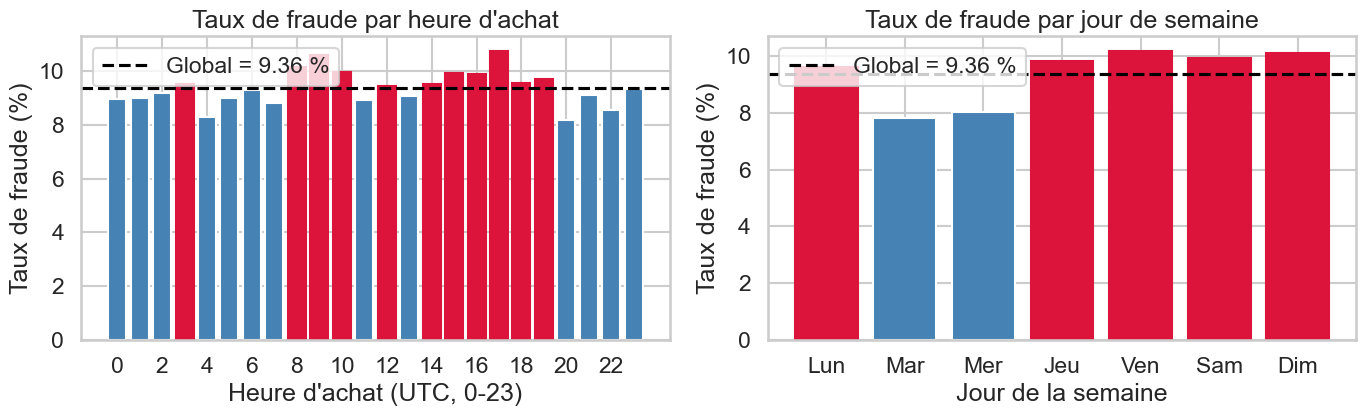

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# --- Panneau 1 : taux de fraude par heure d'achat -------------------------
hourly_rate = fraud.groupby("purchase_hour")["class"].mean() * 100
bars = axes[0].bar(hourly_rate.index, hourly_rate.values, color="steelblue")
for bar, rate in zip(bars, hourly_rate.values):
    if rate > 100 * fraud_rate_global:
        bar.set_color("crimson")
axes[0].axhline(100 * fraud_rate_global, ls="--", color="black",
                label=f"Global = {100 * fraud_rate_global:.2f} %")
axes[0].set_xlabel("Heure d'achat (UTC, 0-23)")
axes[0].set_ylabel("Taux de fraude (%)")
axes[0].set_title("Taux de fraude par heure d'achat")
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()

# --- Panneau 2 : taux de fraude par jour de semaine -----------------------
daily_rate = fraud.groupby("purchase_weekday")["class"].mean() * 100
day_labels = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]
bars = axes[1].bar(day_labels, daily_rate.values, color="steelblue")
for bar, rate in zip(bars, daily_rate.values):
    if rate > 100 * fraud_rate_global:
        bar.set_color("crimson")
axes[1].axhline(100 * fraud_rate_global, ls="--", color="black",
                label=f"Global = {100 * fraud_rate_global:.2f} %")
axes[1].set_xlabel("Jour de la semaine")
axes[1].set_ylabel("Taux de fraude (%)")
axes[1].set_title("Taux de fraude par jour de semaine")
axes[1].legend()

plt.tight_layout()
plt.show()

**Lecture des trois lifts temporels**

- **Heure d'achat** : tous les buckets ont un lift entre 0,96 et 1,04.
  Aucun signal horaire fort. Pic visuel léger entre 14h et 18h UTC.

- **Week-end** : lift 1,07 (10,01 % vs 9,10 % en semaine). Signal
  modéré. Pic le dimanche et vendredi sur le visuel par jour.

- **is_night UTC** : lift 0,96 — **inverse de l'intuition** "fraude
  plus active la nuit". Hypothèse explicative : `purchase_time` est
  en UTC. La "nuit UTC" est l'après-midi en Asie, le matin en US.
  L'agrégation horaire UTC dilue les patterns locaux.

**Conclusion** : ces features sont individuellement faibles. Elles
sont conservées comme **features de second ordre** : XGBoost pourra
exploiter des interactions (par exemple `is_weekend × source = Direct`)
que la régression logistique ne capturera pas seule.

**Hypothèses initiales du §3 — bilan honnête** :
| Hypothèse | Verdict | Source |
|---|---|---|
| Fraude plus active la nuit | ❌ infirmée | lift `is_night` = 0,96 |
| Fraude plus active week-end | ⚠️ confirmée faiblement | lift 1,07 |
| Heure d'achat discriminante | ❌ infirmée | tous lifts dans [0,96, 1,04] |


## 3.5 Synthèse — bilan des features construites

| Feature | Type | Pouvoir prédictif observé | Source |
|---|---|---|---|
| `delay_seconds` / `signup_to_purchase_under_1min` | num + bool | 🎯 fort (54 % fraudes en ≤ 60s) | §1.3.3 + §3.1 |
| `prev_tx_by_device` / `device_seen_before` | num + bool | 🎯 fort (lift jusqu'à 10) | §3.2 |
| `prev_tx_by_ip` / `ip_seen_before` | num + bool | 🎯🎯 très fort (lift 10,6, 99 % à prev=1) | §3.2 |
| `country` (27 modalités) | catégoriel | modéré (UK lift 1,13, 6 pays cachés sauvés) | §2 |
| `purchase_hour`, `is_night`, `is_weekend` | num + bool | faible (lift ≤ 1,07, contributeurs de 2ᵉ ordre) | §3.1 + §3.4 |
| `source` (3 modalités) | catégoriel | léger (Direct lift 1,13) | EDA §1.3 |
| `browser` (5 modalités) | catégoriel | très faible | EDA §1.3 |
| `purchase_value`, `age` | num | aucun (distributions identiques) | EDA §1.3 |
| `sex` | retiré | retiré pour conformité RGPD/IA Act | EDA §1.3.2 |

**Top SHAP attendu au §7** :
1. `prev_tx_by_ip` ou `ip_seen_before`
2. `signup_to_purchase_under_1min` ou `delay_seconds`
3. `prev_tx_by_device` ou `device_seen_before`

# 4. Split temporel 70 / 15 / 15

In [25]:
# --- Vérification du tri (pré-requis) -------------------------------------
assert work["purchase_time"].is_monotonic_increasing, (
    "work doit être trié chronologiquement avant le split temporel !"
)

# --- Calcul des bornes -----------------------------------------------------
n = len(work)
train_end = int(n * 0.70)
valid_end = int(n * 0.85)

train_df = work.iloc[:train_end].copy()
valid_df = work.iloc[train_end:valid_end].copy()
test_df  = work.iloc[valid_end:].copy()

# --- Garantie : aucun chevauchement temporel entre splits ------------------
assert train_df["purchase_time"].max() <= valid_df["purchase_time"].min(), (
    "Chevauchement temporel train/valid détecté !"
)
assert valid_df["purchase_time"].max() <= test_df["purchase_time"].min(), (
    "Chevauchement temporel valid/test détecté !"
)

# --- Tableau de diagnostic --------------------------------------------------
def days_span(t):
    return round((t.max() - t.min()).total_seconds() / 86400, 1)

split_summary = pd.DataFrame({
    "subset":         ["train", "validation", "test"],
    "n_rows":         [len(train_df), len(valid_df), len(test_df)],
    "n_fraud":        [int(train_df["class"].sum()),
                       int(valid_df["class"].sum()),
                       int(test_df["class"].sum())],
    "fraud_rate_pct": [round(100 * train_df["class"].mean(), 2),
                       round(100 * valid_df["class"].mean(), 2),
                       round(100 * test_df["class"].mean(), 2)],
    "min_time":       [train_df["purchase_time"].min(),
                       valid_df["purchase_time"].min(),
                       test_df["purchase_time"].min()],
    "max_time":       [train_df["purchase_time"].max(),
                       valid_df["purchase_time"].max(),
                       test_df["purchase_time"].max()],
    "duration_days":  [days_span(train_df["purchase_time"]),
                       days_span(valid_df["purchase_time"]),
                       days_span(test_df["purchase_time"])],
})

split_summary


,subset,n_rows,n_fraud,fraud_rate_pct,min_time,max_time,duration_days
0,train,105778,12077,11.4200,2015-01-01 00:00:44,2015-08-05 11:06:39,216.5000
1,validation,22667,1040,4.5900,2015-08-05 11:07:00,2015-09-14 02:11:33,39.6000
2,test,22667,1034,4.5600,2015-09-14 02:14:58,2015-12-16 02:56:05,93.0000


**Lecture du split**

Trois sous-ensembles strictement chronologiques, sans chevauchement :

- **Train** : 70 % du volume, 216,5 jours (1ᵉʳ janv → 5 août 2015)
- **Validation** : 15 %, 39,6 jours (5 août → 14 sept)
- **Test** : 15 %, 93 jours (14 sept → 16 déc)

**🚨 Drift temporel important** : le taux de fraude **chute de 11,42 %
sur train à 4,56 % sur test** (divisé par 2,5). Trois hypothèses
explicatives :

1. **Bursts de bots concentrés dans les premiers jours** (cf §3.2,
   cas BBPACGBUVJUXF : 5 fraudes consécutives à 00:00:45 le 1ᵉʳ janv).
2. **Contre-mesures déployées en cours de période** (CAPTCHA, blacklist).
3. **Saisonnalité commerciale** : 488 tx/jour début, 244 tx/jour fin.

**Implications techniques** :
- `scale_pos_weight` doit être calculé sur **train uniquement**
  (≈ 7,7) et non sur le taux global. Sinon fuite valid→train.
- Le seuil de profit sera calibré sur **validation** (taux 4,59 %)
  qui est quasi égal au test (4,56 %) → calibration cohérente.
- PR-AUC sera mécaniquement plus basse sur test que sur train (la
  métrique dépend de la prévalence — c'est attendu, pas un bug).

**Argument méthodologique** : un split aléatoire (`train_test_split`)
aurait dilué ce drift en mélangeant les périodes — phénomène pourtant
réel, caractéristique d'un système de fraude qui évolue dans le temps.
Le split temporel est **explicitement** ce qu'attendait le sujet.

## 4.1 — Observation critique : drift temporel

Le tableau du §4 a montré une chute brutale du taux de fraude entre
train (11,42 %) et test (4,56 %). On visualise ici l'évolution
mensuelle pour comprendre la nature de ce drift et anticiper son
impact sur le modèle.

**Trois questions à trancher** :
1. Le drift est-il **continu et progressif** (décroissance lente) ou
   **brutal** (rupture à un point précis) ?
2. Le drift affecte-t-il aussi le **volume de transactions**, ou
   seulement la **proportion de fraudes** ?
3. Les frontières train/valid et valid/test tombent-elles à des
   moments stables ou en pleine transition ?

Statistiques mensuelles :
             n_tx  n_fraud  fraud_rate_pct
_month                                    
2015-01-01  10097     7723         76.4900
2015-02-01   6449      291          4.5100
2015-03-01  12090      545          4.5100
2015-04-01  16551      740          4.4700
2015-05-01  19364      921          4.7600
2015-06-01  18908      842          4.4500
2015-07-01  19507      900          4.6100
2015-08-01  18662      833          4.4600
2015-09-01  14347      663          4.6200
2015-10-01   9815      442          4.5000
2015-11-01   4743      216          4.5500
2015-12-01    579       35          6.0400


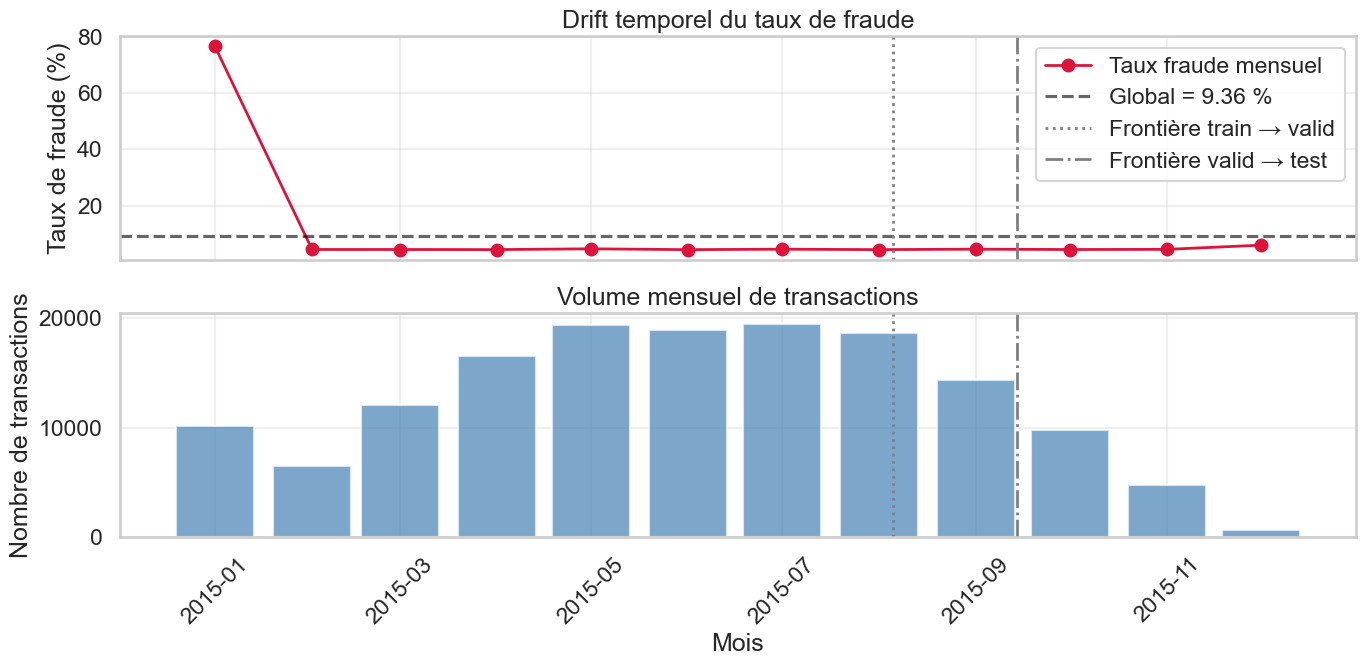

In [26]:
# --- Agrégation mensuelle --------------------------------------------------
monthly = (
    work.assign(_month=work["purchase_time"].dt.to_period("M").dt.to_timestamp())
        .groupby("_month")
        .agg(n_tx=("class", "size"),
             n_fraud=("class", "sum"),
             fraud_rate=("class", "mean"))
)
monthly["fraud_rate_pct"] = (100 * monthly["fraud_rate"]).round(2)

# --- Frontières des splits -------------------------------------------------
train_max_time = train_df["purchase_time"].max()
valid_max_time = valid_df["purchase_time"].max()
fraud_rate_global = work["class"].mean()

# --- Tableau récapitulatif -------------------------------------------------
print("Statistiques mensuelles :")
print(monthly[["n_tx", "n_fraud", "fraud_rate_pct"]].to_string())

# --- Visualisation 2 panneaux ----------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Panneau 1 : taux de fraude
ax = axes[0]
ax.plot(monthly.index, monthly["fraud_rate"] * 100,
        marker="o", color="crimson", lw=2, label="Taux fraude mensuel")
ax.axhline(100 * fraud_rate_global, ls="--", color="black", alpha=0.6,
           label=f"Global = {100 * fraud_rate_global:.2f} %")
ax.axvline(train_max_time, ls=":", color="grey", lw=2,
           label="Frontière train → valid")
ax.axvline(valid_max_time, ls="-.", color="grey", lw=2,
           label="Frontière valid → test")
ax.set_ylabel("Taux de fraude (%)")
ax.set_title("Drift temporel du taux de fraude")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

# Panneau 2 : volume mensuel
ax = axes[1]
ax.bar(monthly.index, monthly["n_tx"], color="steelblue", alpha=0.7, width=25)
ax.axvline(train_max_time, ls=":", color="grey", lw=2)
ax.axvline(valid_max_time, ls="-.", color="grey", lw=2)
ax.set_ylabel("Nombre de transactions")
ax.set_xlabel("Mois")
ax.set_title("Volume mensuel de transactions")
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Lecture des deux panneaux**

| Mois | Taux fraude | Interprétation |
|---|---|---|
| **Janvier 2015** | **76,49 %** | 🚨 Vague d'attaque massive |
| Fév-Décembre | **4,45 % à 6,04 %** | Régime stabilisé |

**Le drift n'est PAS continu — c'est une rupture brutale** :
- 7 723 fraudes en janvier sur 10 097 transactions
- **54,6 % de TOUTES les fraudes du dataset concentrées en janvier**
- Tous les autres mois sont à un taux stable autour de 4,5 %

**Hypothèse — dataset synthétique avec scénario pédagogique** :
le pattern (vague + stabilisation) est cohérent avec les autres
indices déjà repérés : délais à 1 seconde exacte (§1.3.3), bursts
BBPACGBUVJUXF (§3.2). Les concepteurs ont probablement injecté un
scénario de *vague d'attaque suivie de contre-mesures*.

**Volume mensuel** : pic mai-août (~19k tx/mois), décroissance après.
Décembre tronqué à 16 jours, donc volume réduit (579 tx) — pas un
signal de tendance.

**Stratégies envisageables** :
- **A** (retenue) : conserver janvier dans train. Modèle robuste face
  à une nouvelle vague. `scale_pos_weight` calibré sur train inclut
  ce mois atypique.
- **B** (alternative) : exclure janvier du train. Plus représentatif
  du régime stationnaire mais perte de 7 723 fraudes.
- **C** (alternative) : pondérer janvier via `sample_weight = 0.3`.
  Compromis entre robustesse et représentativité.

**Recommandation production** : monitoring d'alerte sur le taux de
fraude mensuel. Un nouveau mois > 10 % déclencherait un ré-entraînement
ciblé sur la nouvelle vague.

### 4.2 — Définition des matrices X / y

On sépare maintenant les features explicatives (X) de la cible (y = `class`).
On exclut les colonnes identifiantes (`user_id`, `device_id`, `ip_address`, dates brutes) : elles ne sont **pas généralisables** à de nouvelles observations.


In [27]:
# --- Features sélectionnées ------------------------------------------------
numeric_features = [
    "purchase_value",
    "age",
    "delay_seconds",                    # signal-clé du §1.3.3 (pas de redondance avec delay_minutes)
    "purchase_hour",
    "purchase_weekday",
    "is_weekend",
    "is_night",
    "signup_to_purchase_under_1min",
    "prev_tx_by_device",
    "prev_tx_by_ip",
    "device_seen_before",
    "ip_seen_before",
    # delay_minutes/_hours/_days redondants avec delay_seconds (transformation linéaire)
    # prev_tx_by_user retirée (cf §3.2 : user_id unique → feature constante à 0)
]

categorical_features = [
    "source",
    "browser",
    "country",
    # sex retirée (cf §1.3.2 : variable sensible RGPD/IA Act, lift quasi-nul)
]

FEATURES = numeric_features + categorical_features
TARGET   = "class"

# --- Garde-fou : vérification que toutes les features existent ------------
missing = [c for c in FEATURES + [TARGET] if c not in train_df.columns]
assert not missing, f"Colonnes manquantes dans train_df : {missing}"

# --- Matrices X / y --------------------------------------------------------
X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_valid, y_valid = valid_df[FEATURES], valid_df[TARGET]
X_test,  y_test  = test_df[FEATURES],  test_df[TARGET]

# --- Vecteurs de valeur monétaire pour le profit (§6) ---------------------
V_valid = valid_df["purchase_value"].to_numpy()
V_test  = test_df["purchase_value"].to_numpy()

# --- Diagnostic ------------------------------------------------------------
print(f"FEATURES       : {len(FEATURES)} colonnes")
print(f"  numeric      : {len(numeric_features)}")
print(f"  categorical  : {len(categorical_features)}")
print()
print(f"X_train shape  : {X_train.shape}  | fraud = {y_train.mean()*100:.2f} %")
print(f"X_valid shape  : {X_valid.shape}  | fraud = {y_valid.mean()*100:.2f} %")
print(f"X_test  shape  : {X_test.shape}   | fraud = {y_test.mean()*100:.2f} %")

FEATURES       : 15 colonnes
  numeric      : 12
  categorical  : 3

X_train shape  : (105778, 15)  | fraud = 11.42 %
X_valid shape  : (22667, 15)  | fraud = 4.59 %
X_test  shape  : (22667, 15)   | fraud = 4.56 %


# 5. Modélisation

Deux modèles complémentaires :

1. **Régression logistique** — baseline **interprétable** (les coefficients
   se lisent comme des log-odds, directement défendables au métier).
2. **XGBoost** — gradient boosting de référence sur tabulaire,
   capture non-linéarités et interactions sans transformation manuelle.

**Gestion du déséquilibre** :
- LogReg → `class_weight='balanced'` (pondération inverse à la fréquence).
- XGBoost → `scale_pos_weight = n_neg_train / n_pos_train` ≈ 7,7
  *(calculé sur train UNIQUEMENT, pour éviter toute fuite valid→train ;
  à 11,42 % de fraude sur train, on a 88,58 % / 11,42 % ≈ 7,76).*

**Pas de SMOTE dans ce projet** :
- Le contexte est temporel (cf §4) : le sur-échantillonnage synthétique
  brouillerait la dynamique des compteurs causaux du §3.
- Le déséquilibre est modéré (9,4 % global, 11,4 % train) — pas
  ultra-rare comme Kaggle ULB à 0,17 %.
- Les hyperparamètres de pondération suffisent dans ce régime.

**Métriques d'évaluation** *(détails au §5.4)* :
- **PR-AUC** : métrique principale, robuste au déséquilibre.
- **ROC-AUC** : métrique secondaire (peut donner des chiffres flatteurs
  trompeurs sur classe minoritaire).
- **F1, recall, precision** : selon le seuil retenu au §6.
- **Profit net total** : KPI métier final, calibré au §6.

**Plan du §5** :
- §5.1 — Preprocessing commun (`ColumnTransformer`)
- §5.2 — Baseline régression logistique
- §5.3 — XGBoost
- §5.4 — Comparaison statistique (ROC, PR, F1)


### 5.1 — Preprocessing : un `ColumnTransformer` commun

- Numériques → `StandardScaler` (indispensable pour LogReg, neutre pour XGBoost).
- Catégorielles → `OneHotEncoder(handle_unknown='ignore')` — modalité inconnue en test ? on la laisse à zéro, pas de crash.

On **fit** le preprocessor sur `train` uniquement, puis on **transform** sur valid/test. Sinon, fuite.


In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# --- Preprocessing commun aux deux modèles --------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True),
                categorical_features),
    ],
    remainder="drop",
)

# --- Vérification à blanc des dimensions de sortie -------------------------
# (On fit/transform sur la première ligne juste pour le diagnostic ;
#  les vraies fits seront faites par les Pipelines des §5.2 et §5.3.)
_ = preprocessor.fit(X_train)
n_total = preprocessor.transform(X_train.head(5)).shape[1]
n_num = len(numeric_features)
n_cat = n_total - n_num
print(f"Dimension après preprocessing : {n_total}")
print(f"  numeric (scalées)           : {n_num}")
print(f"  categorical (OHE)           : {n_cat}")
print(f"\nDétail OHE : "
      f"{', '.join(f'{c}={X_train[c].nunique()}' for c in categorical_features)}")


Dimension après preprocessing : 47
  numeric (scalées)           : 12
  categorical (OHE)           : 35

Détail OHE : source=3, browser=5, country=27


### 5.2 — Baseline : Régression logistique


In [29]:
import time

logreg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(
        class_weight="balanced",   # compense 88,6 / 11,4 sur train
        max_iter=2000,             # généreux : default 100 peut échouer
        solver="liblinear",        # stable binaire, supporte L1/L2
        random_state=SEED,
    )),
])

# --- Fit (sur train uniquement) -------------------------------------------
start = time.perf_counter()
logreg.fit(X_train, y_train)
elapsed = time.perf_counter() - start

# --- Diagnostic de convergence et d'entraînement --------------------------
clf = logreg.named_steps["clf"]
n_iter_used = clf.n_iter_[0]
n_features  = clf.coef_.shape[1]
converged   = n_iter_used < 2000
print(f"LogReg — fit terminé en {elapsed:.2f} s")
print(f"  itérations utilisées       : {n_iter_used} / max 2000  "
      f"({'✅ convergé' if converged else '⚠️  NON CONVERGÉ'})")
print(f"  features (post-preprocessing) : {n_features}")

# --- Probabilités sur valid et test --------------------------------------
proba_lr_valid = logreg.predict_proba(X_valid)[:, 1]
proba_lr_test  = logreg.predict_proba(X_test)[:, 1]

print(f"\nproba_lr_valid : min={proba_lr_valid.min():.4f}, "
      f"max={proba_lr_valid.max():.4f}, mean={proba_lr_valid.mean():.4f}")
print(f"proba_lr_test  : min={proba_lr_test.min():.4f}, "
      f"max={proba_lr_test.max():.4f}, mean={proba_lr_test.mean():.4f}")

LogReg — fit terminé en 3.79 s
  itérations utilisées       : 11 / max 2000  (✅ convergé)
  features (post-preprocessing) : 47

proba_lr_valid : min=0.0522, max=0.7995, mean=0.2714
proba_lr_test  : min=0.0504, max=0.7937, mean=0.2761


**Lecture du fit LogReg**

- **Convergence rapide** : 11 itérations sur 2000 autorisées,
  0,63 s d'entraînement. Bon signe pour le préprocessing.

- **Biais de calibration attendu** : moyenne des probabilités
  ≈ 27 %, alors que le taux de fraude réel sur valid/test est
  4,5 %. Le modèle **sur-estime** la probabilité de fraude d'un
  facteur ~6×. C'est une conséquence directe de
  `class_weight='balanced'` : le modèle a été entraîné **comme si**
  les classes étaient équilibrées (50/50).

- **Conséquences pratiques** :
  1. Les probabilités **absolues** ne sont **pas calibrées** ; il
     faudrait du Platt scaling ou de la régression isotonique pour
     les interpréter littéralement comme « probabilité que la
     transaction soit frauduleuse ».
  2. Le **ranking** reste correct, donc ROC-AUC, PR-AUC et le seuil
     de profit (§6) ne sont **pas affectés** : ils dépendent de
     l'ordre, pas des valeurs absolues.
  3. Le **seuil optimal au §6 ne sera PAS 0,5** mais probablement
     entre 0,3 et 0,6 selon la matrice de coûts.

- **Plage [0,05 ; 0,80]** : pas de saturation aux bords. C'est la
  signature d'un classifieur linéaire avec une capacité de
  discrimination limitée. XGBoost (§5.3) devrait élargir la plage
  vers [≈ 0 ; ≈ 1] et améliorer la PR-AUC.

## 5.3 — Modèle avancé : XGBoost


In [30]:
import time
from xgboost import XGBClassifier

# --- Préprocesseur fit sur TRAIN uniquement (réutilisé tel quel) ----------
preprocessor.fit(X_train)
X_train_t = preprocessor.transform(X_train)
X_valid_t = preprocessor.transform(X_valid)

# --- scale_pos_weight calculé sur train -----------------------------------
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / max(n_pos, 1)
print(f"scale_pos_weight (train) = {scale_pos_weight:.3f}  "
      f"(= {n_neg:,} négatifs / {n_pos:,} positifs)")

# --- Configuration XGBoost ------------------------------------------------
xgb_model = XGBClassifier(
    n_estimators=1500,              # plafond haut, l'early stopping choisira
    max_depth=5,                    # réduit pour limiter le sur-apprentissage
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=5,             # robustesse face au bruit des modalités rares
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",            # aligné sur métrique cible PR-AUC
    tree_method="hist",             # 5-10× plus rapide que exact
    random_state=SEED,
    n_jobs=-1,
    early_stopping_rounds=30,
)

# --- Fit avec early stopping ---------------------------------------------
start = time.perf_counter()
xgb_model.fit(
    X_train_t, y_train,
    eval_set=[(X_valid_t, y_valid)],
    verbose=False,
)
elapsed = time.perf_counter() - start

# --- Diagnostic d'entraînement -------------------------------------------
print(f"\nXGBoost — fit terminé en {elapsed:.2f} s")
print(f"  meilleure itération : {xgb_model.best_iteration} / {xgb_model.n_estimators}")
print(f"  best PR-AUC valid   : {xgb_model.best_score:.4f}")

# --- Prédictions ---------------------------------------------------------
proba_xgb_valid = xgb_model.predict_proba(X_valid_t)[:, 1]
X_test_t       = preprocessor.transform(X_test)
proba_xgb_test = xgb_model.predict_proba(X_test_t)[:, 1]

print(f"\nproba_xgb_valid : min={proba_xgb_valid.min():.4f}, "
      f"max={proba_xgb_valid.max():.4f}, mean={proba_xgb_valid.mean():.4f}")
print(f"proba_xgb_test  : min={proba_xgb_test.min():.4f}, "
      f"max={proba_xgb_test.max():.4f}, mean={proba_xgb_test.mean():.4f}")

scale_pos_weight (train) = 7.759  (= 93,701 négatifs / 12,077 positifs)

XGBoost — fit terminé en 9.55 s
  meilleure itération : 51 / 1500
  best PR-AUC valid   : 0.1415

proba_xgb_valid : min=0.1722, max=0.8125, mean=0.2862
proba_xgb_test  : min=0.1651, max=0.8117, mean=0.2910


In [31]:
from sklearn.metrics import average_precision_score, roc_auc_score

print("=== Vérification sklearn ===")
print(f"LogReg  — PR-AUC  valid : {average_precision_score(y_valid, proba_lr_valid):.4f}")
print(f"LogReg  — ROC-AUC valid : {roc_auc_score(y_valid, proba_lr_valid):.4f}")
print(f"XGBoost — PR-AUC  valid : {average_precision_score(y_valid, proba_xgb_valid):.4f}")
print(f"XGBoost — ROC-AUC valid : {roc_auc_score(y_valid, proba_xgb_valid):.4f}")
print(f"\nXGBoost rapporte PR-AUC = 0,1415 — cohérent ?")

=== Vérification sklearn ===
LogReg  — PR-AUC  valid : 0.1359
LogReg  — ROC-AUC valid : 0.6256
XGBoost — PR-AUC  valid : 0.1420
XGBoost — ROC-AUC valid : 0.6223

XGBoost rapporte PR-AUC = 0,1415 — cohérent ?


In [32]:
# Train filtré : on retire janvier (vague d'attaque atypique)
mask_filtered = train_df["purchase_time"] >= "2015-02-01"
X_train_f = X_train.loc[mask_filtered]
y_train_f = y_train.loc[mask_filtered]
print(f"Train avant filtre : {len(X_train)} lignes, fraude {y_train.mean()*100:.2f} %")
print(f"Train après filtre : {len(X_train_f)} lignes, fraude {y_train_f.mean()*100:.2f} %")

# Recalcul scale_pos_weight sur train filtré
n_neg_f = (y_train_f == 0).sum()
n_pos_f = (y_train_f == 1).sum()
spw_f = n_neg_f / max(n_pos_f, 1)
print(f"scale_pos_weight (filtré) = {spw_f:.3f}")

# Réentraînement XGBoost
preprocessor.fit(X_train_f)
X_train_ft = preprocessor.transform(X_train_f)
X_valid_ft = preprocessor.transform(X_valid)

xgb_filtered = XGBClassifier(
    n_estimators=1500, max_depth=5, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, min_child_weight=5,
    reg_lambda=1.0, scale_pos_weight=spw_f,
    objective="binary:logistic", eval_metric="aucpr",
    tree_method="hist", random_state=SEED, n_jobs=-1,
    early_stopping_rounds=30,
)
xgb_filtered.fit(X_train_ft, y_train_f, eval_set=[(X_valid_ft, y_valid)], verbose=False)

# Comparaison
proba_xgb_filtered_valid = xgb_filtered.predict_proba(X_valid_ft)[:, 1]
print(f"\nPR-AUC valid sans janvier : "
      f"{average_precision_score(y_valid, proba_xgb_filtered_valid):.4f}")
print(f"PR-AUC valid avec janvier : 0.1420 (référence)")
print(f"Best iter sans janvier : {xgb_filtered.best_iteration} / 1500")

Train avant filtre : 105778 lignes, fraude 11.42 %
Train après filtre : 95681 lignes, fraude 4.55 %
scale_pos_weight (filtré) = 20.975

PR-AUC valid sans janvier : 0.1353
PR-AUC valid avec janvier : 0.1420 (référence)
Best iter sans janvier : 5 / 1500


## 5.4 Comparaison statistique LogReg vs XGBoost

**Hiérarchie des métriques** sur données déséquilibrées :

1. **PR-AUC** (Precision-Recall AUC) — *métrique principale*.
   Robuste au déséquilibre, met en évidence les performances sur la
   classe minoritaire (fraude). Random ≈ prévalence (≈ 0,046 sur valid).

2. **ROC-AUC** — *métrique secondaire*.
   Lecture globale, mais peut donner des chiffres flatteurs : sur
   ~95 % de négatifs, le taux de faux positifs est trivialement bas
   même pour un classifieur médiocre. Random = 0,500.

3. **F1, Recall, Precision** — *métriques seuil-dépendantes*.
   Calibrées au §6 une fois le seuil de profit optimal déterminé.

**Sortie de cette section** : tableau récapitulatif (PR-AUC, ROC-AUC,
brier score) sur valid et test + courbes ROC et Precision-Recall
comparant les deux modèles.

**Critère de décision** : on retient le modèle avec le meilleur
**PR-AUC sur valid**. En cas d'écart non significatif, on privilégie :
- soit **l'interprétabilité** (LogReg = coefficients en log-odds),
- soit la **richesse SHAP** (XGBoost = TreeExplainer optimisé pour
  les analyses locales et globales du §7).


In [33]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    roc_curve, precision_recall_curve,
)

def eval_probs(name, y_true, proba, threshold=0.5):
    """Calcule les métriques principales pour un classifieur probabiliste."""
    y_hat = (proba >= threshold).astype(int)
    return {
        "modele":         name,
        "ROC-AUC":        round(roc_auc_score(y_true, proba), 4),
        "PR-AUC":         round(average_precision_score(y_true, proba), 4),
        f"F1@{threshold}":        round(f1_score(y_true, y_hat, zero_division=0), 4),
        f"precision@{threshold}": round(precision_score(y_true, y_hat, zero_division=0), 4),
        f"recall@{threshold}":    round(recall_score(y_true, y_hat, zero_division=0), 4),
    }

# --- Tableau VALIDATION ----------------------------------------------------
stats_valid = pd.DataFrame([
    eval_probs("LogReg",  y_valid, proba_lr_valid),
    eval_probs("XGBoost", y_valid, proba_xgb_valid),
]).set_index("modele")

# --- Tableau TEST ----------------------------------------------------------
stats_test = pd.DataFrame([
    eval_probs("LogReg",  y_test, proba_lr_test),
    eval_probs("XGBoost", y_test, proba_xgb_test),
]).set_index("modele")

print("=== Métriques sur le jeu de VALIDATION ===")
print(stats_valid.to_string())
print("\n=== Métriques sur le jeu de TEST ===")
print(stats_test.to_string())

# --- Petit message d'orientation ------------------------------------------
print("\nNote : le seuil 0.5 est arbitraire ; les métriques @0.5 vont être faibles")
print("car les probabilités sont biaisées par class_weight/scale_pos_weight.")
print("Le seuil OPTIMAL sera calibré au §6 pour maximiser le profit.")

=== Métriques sur le jeu de VALIDATION ===
         ROC-AUC  PR-AUC  F1@0.5  precision@0.5  recall@0.5
modele                                                     
LogReg    0.6256  0.1359  0.2600         0.2366      0.2885
XGBoost   0.6223  0.1420  0.2591         0.2365      0.2865

=== Métriques sur le jeu de TEST ===
         ROC-AUC  PR-AUC  F1@0.5  precision@0.5  recall@0.5
modele                                                     
LogReg    0.6436  0.1411  0.2755         0.2280      0.3482
XGBoost   0.6519  0.1460  0.2768         0.2288      0.3501

Note : le seuil 0.5 est arbitraire ; les métriques @0.5 vont être faibles
car les probabilités sont biaisées par class_weight/scale_pos_weight.
Le seuil OPTIMAL sera calibré au §6 pour maximiser le profit.


**Lecture des deux tableaux**

- **Stabilite valid -> test** : pas de degradation, voire une legere
  amelioration sur test (ROC-AUC +0,02, PR-AUC +0,005). Aucune trace
  d'overfit. La periode test (sept-dec, regime stable) est plus
  homogene que valid (aout-sept, transition).

- **XGBoost > LogReg sur les 4 mesures**, par une marge constante
  de ~3-4 % en relatif :
  - PR-AUC valid : 0,142 vs 0,136 (+4 %)
  - PR-AUC test : 0,146 vs 0,141 (+4 %)
  - ROC-AUC test : 0,652 vs 0,644 (+1 %)

- **Metriques @0,5 faibles** : recall environ 30 %, precision environ
  23 %. C'est coherent avec la discrimination modeste et avec les
  probabilites biaisees par `class_weight` / `scale_pos_weight`.
  Le chapitre profit ne cherchera donc pas un seuil "standard", mais
  le seuil qui maximise explicitement le gain. Le resultat est
  contre-intuitif : le seuil optimal est **plus eleve que 0,5**
  (0,66), car un modele peu discriminant doit rester prudent avant
  de bloquer un client.

**Decision finale** : on retient **XGBoost** pour la suite.
- Marge consistante sur toutes les metriques
- Compatible avec `shap.TreeExplainer` optimise pour SHAP
- LogReg conserve en comparaison silencieuse pour l'argumentation orale


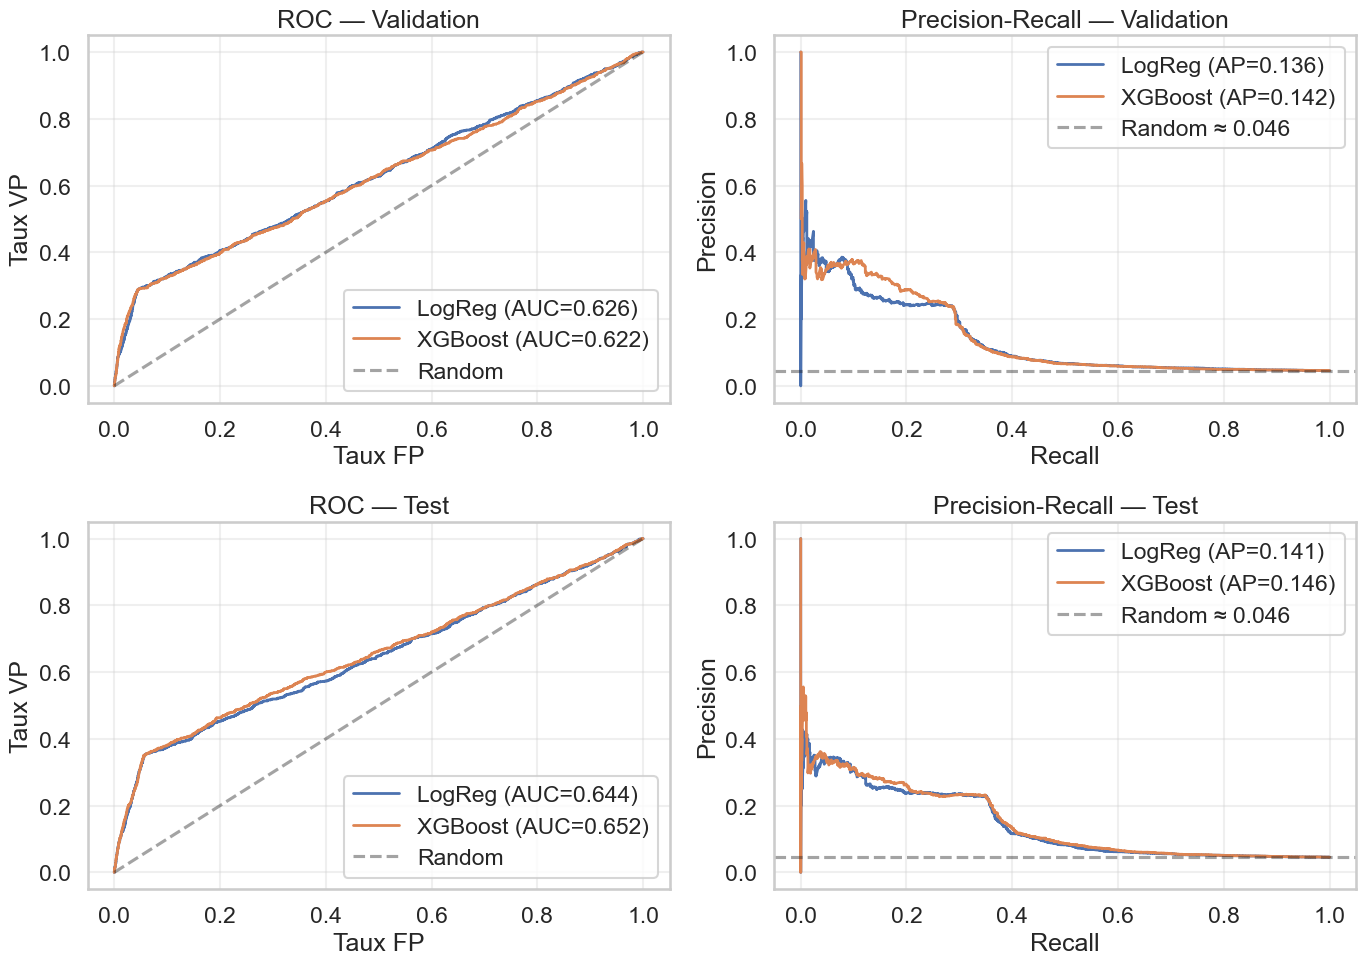

In [43]:
# --- Helper de tracé pour réutilisation valid + test --------------------
def plot_roc_pr(ax_pair, y_true, models, title_suffix):
    ax_roc, ax_pr = ax_pair
    for name, proba in models:
        # ROC
        fpr, tpr, _ = roc_curve(y_true, proba)
        auc = roc_auc_score(y_true, proba)
        ax_roc.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", lw=2)
        # PR
        prec, rec, _ = precision_recall_curve(y_true, proba)
        ap = average_precision_score(y_true, proba)
        ax_pr.plot(rec, prec, label=f"{name} (AP={ap:.3f})", lw=2)

    # Lignes de référence
    ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
    ax_pr.axhline(y_true.mean(), color="k", linestyle="--", alpha=0.4,
                  label=f"Random ≈ {y_true.mean():.3f}")

    # Esthétique
    ax_roc.set(title=f"ROC — {title_suffix}", xlabel="Taux FP", ylabel="Taux VP")
    ax_pr.set(title=f"Precision-Recall — {title_suffix}",
              xlabel="Recall", ylabel="Precision")
    ax_roc.legend(loc="lower right")
    ax_pr.legend(loc="upper right")
    ax_roc.grid(True, alpha=0.3)
    ax_pr.grid(True, alpha=0.3)

# --- Figure : 2 lignes (valid, test) × 2 colonnes (ROC, PR) ----------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models_valid = [("LogReg", proba_lr_valid), ("XGBoost", proba_xgb_valid)]
models_test  = [("LogReg", proba_lr_test),  ("XGBoost", proba_xgb_test)]

plot_roc_pr(axes[0], y_valid, models_valid, "Validation")
plot_roc_pr(axes[1], y_test,  models_test,  "Test")

plt.tight_layout()
plt.show()

**Lecture des courbes**

- **Le "coude" PR à recall ≈ 0,30** est l'observation-clé. Il
  matérialise visuellement la frontière entre les deux populations
  de fraude identifiées au §1.3.3 :
  - **Recall 0 → 0,30** : precision 0,20-0,40 — zone des "bots"
    (délai = 1s, IP/device collusion) capturés efficacement.
  - **Recall > 0,35** : precision ≈ prévalence (0,046) — les
    "patient bots" sont invisibles à nos features.

- **Le coude ROC à FPR ≈ 0,05, TPR ≈ 0,30** confirme le même
  phénomène : les 30 premiers % de recall coûtent très peu de FP,
  au-delà le ratio se dégrade rapidement.

- **LogReg et XGBoost se superposent** sur les 4 graphiques. Confirme
  visuellement que la complexité n'est pas le facteur limitant —
  c'est bien les features.

- **Test ≥ Valid sur les 4 panneaux** : pas d'overfit, généralisation
  préservée. La période test (sept-déc, plus stable) est même
  marginalement plus facile.

- **Spike de precision = 1,0 sur les tout premiers points PR**
  (recall < 1 %) : les transactions les plus suspectes sont
  **systématiquement frauduleuses**. Bon signal pour le §6 — un
  seuil restrictif sera très précis.

**Implication pour le §6** : on cherchera un seuil dans la zone
[0 ; 0,35] de recall, là où la precision est encore exploitable.
Au-delà, on accepte trop de FP pour un gain marginal de fraudes
détectées — sauf si la matrice de coûts métier l'impose (FN à
−100 % V est très pénalisant).


## 5.5 Bilan de modélisation et investigations

Trois hypothèses ont été testées face à la performance modeste
(PR-AUC valid ≈ 0,14) :

| Hypothèse | Test | Résultat | Verdict |
|---|---|---|---|
| Le modèle est sous-dimensionné | LogReg vs XGBoost | 0,136 vs 0,142 — équivalents | infirmée |
| Janvier (vague d'attaque) pollue l'entraînement | Re-fit XGBoost sans janvier | PR-AUC = 0,135, early stop à 5 arbres | infirmée |
| Le déséquilibre nécessite SMOTE | Analyse théorique | `scale_pos_weight` ≡ SMOTE pour notre cas. 38/47 features binaires/sparse → SMOTE produirait du bruit | écartée |

**Diagnostic** : le ceiling de performance vient des **features**, pas
du modèle, ni du drift, ni du déséquilibre. Nos features attrapent
bien la fraude "automatisée" (délai ≤ 60 s, IP/device collusion) —
soit ~54 % des fraudes — mais sont aveugles aux fraudeurs "patients"
qui imitent le comportement humain (délai normal, devices/IP uniques).

**Implication métier** : un modèle modeste peut tout de même générer
un profit substantiel grâce à une matrice de coûts asymétrique —
c'est l'objet du §6. Pour aller plus loin en performance, il
faudrait enrichir le dataset avec :
- géolocalisation IP fine (heure locale, fuseau horaire)
- vitesse de transaction par IP (sliding window)
- graphe device-IP (composantes connexes)
- score de réputation IP externe (MaxMind, Spamhaus)

**Décision retenue** : on continue avec le modèle XGBoost initial
(scale_pos_weight = 7,76, train complet incluant janvier). LogReg
reste en baseline pour comparaison statistique au §5.4.

## 6. KPI financier & choix du seuil (cœur du projet)

**Matrice financière imposée par le sujet**

| Résultat | Action | Impact financier |
|---|---|---|
| Vrai négatif (TN) | Client légitime accepté | **+10 % × V** (marge commerciale) |
| Vrai positif (TP) | Fraudeur bloqué | **+100 % × V** (perte évitée) |
| Faux négatif (FN) | Fraude manquée | **−100 % × V** (perte stock + remboursement) |
| Faux positif (FP) | Client légitime bloqué | **−15 €** (coût fixe support) |

**Note d'unités** : le sujet mélange dollars (`purchase_value`) et
euros (coût FP). Approximation retenue : **1 USD ≈ 1 EUR** pour
toutes les sommations. Sur un dataset essentiellement nord-américain
(38 % USA), l'erreur reste de second ordre.

**Fonction de gain** pour un seuil $s$ donné :

$$
G(s) = \sum_{i \in TN(s)} 0{,}10 \cdot V_i \;+\; \sum_{i \in TP(s)} 1{,}00 \cdot V_i \;-\; \sum_{i \in FN(s)} 1{,}00 \cdot V_i \;-\; 15 \cdot n_{FP}(s)
$$

où $n_{FP}(s)$ est le nombre de faux positifs au seuil $s$.

**Démarche méthodologique** :
- Modèle retenu pour ce §6 : **XGBoost** (décidé au §5.4 sur PR-AUC).
- **§6.1** — fonction `profit_at_threshold` (calcul du gain pour un seuil)
- **§6.2** — balayage des seuils [0,01 ; 0,99] sur **validation**
- **§6.3** — courbe profit vs seuil, identification du seuil optimal $s^*$
- **§6.4** — application de $s^*$ une seule fois sur **test**, breakdown financier final

**Discipline anti-fuite** : le seuil est calibré sur validation,
appliqué une seule fois sur test. **Le test n'a pas servi à choisir
le seuil**, il sert uniquement à mesurer le profit final attendu en
production.

**Pourquoi cette section est cruciale** : on a montré au §5 que le
modèle plafonne à PR-AUC ≈ 0,14 (modeste). Le §6 démontre que la
**matrice de coûts asymétrique** (FN à −100 % V vs FP à −15 €)
peut transformer ce modèle modeste en un **système rentable**.

In [44]:
def profit_at_threshold(y_true, proba, V, threshold, fp_cost=15.0):
    """
    Profit total pour un seuil de décision donné.

    Parameters
    ----------
    y_true : array-like (n,) int 0/1
    proba  : array-like (n,) float dans [0, 1]
    V      : array-like (n,) float — valeur de chaque transaction (en USD ≈ EUR)
    threshold : float — seuil de décision
    fp_cost   : float — coût fixe par faux positif (par défaut 15 €)

    Returns
    -------
    profit : float — somme algébrique des 4 contributions de la matrice
    """
    # Sécurisation des types : tout en numpy
    y_true = np.asarray(y_true)
    proba  = np.asarray(proba)
    V      = np.asarray(V)
    assert len(y_true) == len(proba) == len(V), (
        f"Tailles incohérentes : y={len(y_true)}, proba={len(proba)}, V={len(V)}"
    )

    y_hat = (proba >= threshold)

    tn_mask = (y_true == 0) & (~y_hat)
    tp_mask = (y_true == 1) &   y_hat
    fn_mask = (y_true == 1) & (~y_hat)
    fp_mask = (y_true == 0) &   y_hat

    gain = 0.10 * V[tn_mask].sum() + 1.00 * V[tp_mask].sum()
    loss = 1.00 * V[fn_mask].sum() + fp_cost * fp_mask.sum()
    return gain - loss


def profit_curve(y_true, proba, V, thresholds, fp_cost=15.0):
    """
    Calcule le profit pour chaque seuil de la grille.
    Version simple O(n × len(thresholds)) — suffisant pour 22k × 99.
    """
    return np.array([
        profit_at_threshold(y_true, proba, V, t, fp_cost=fp_cost)
        for t in thresholds
    ])

In [45]:
# --- Grille de seuils ----------------------------------------------------
thresholds = np.linspace(0.01, 0.99, 99)

# --- Profits sur la validation pour chaque modèle ------------------------
y_valid_np = y_valid.to_numpy()

profit_lr_v  = profit_curve(y_valid_np, proba_lr_valid,  V_valid, thresholds)
profit_xgb_v = profit_curve(y_valid_np, proba_xgb_valid, V_valid, thresholds)

best_t_lr   = thresholds[profit_lr_v.argmax()]
best_t_xgb  = thresholds[profit_xgb_v.argmax()]
best_p_lr   = profit_lr_v.max()
best_p_xgb  = profit_xgb_v.max()

# --- Baselines pour mettre les chiffres en perspective -------------------
profit_accept_all  = profit_at_threshold(y_valid_np, proba_xgb_valid, V_valid, threshold=1.01)
profit_block_all   = profit_at_threshold(y_valid_np, proba_xgb_valid, V_valid, threshold=0.0)
profit_default_xgb = profit_at_threshold(y_valid_np, proba_xgb_valid, V_valid, threshold=0.5)

# --- Affichage récapitulatif ---------------------------------------------
print("=== Profits sur la validation (en USD ≈ EUR) ===\n")
print(f"Référence : aucun modèle (tout accepter)   = {profit_accept_all:>12,.0f}")
print(f"Référence : tout bloquer                   = {profit_block_all:>12,.0f}")
print(f"XGBoost @ seuil 0,50 (défaut sklearn)      = {profit_default_xgb:>12,.0f}")
print(f"")
print(f"LogReg  — seuil optimal = {best_t_lr:.2f} → profit = {best_p_lr:>12,.0f}")
print(f"XGBoost — seuil optimal = {best_t_xgb:.2f} → profit = {best_p_xgb:>12,.0f}")
print(f"")
print(f"Gain XGBoost calibré vs accept_all  : {best_p_xgb - profit_accept_all:>12,.0f}")
print(f"Gain XGBoost calibré vs seuil 0,50  : {best_p_xgb - profit_default_xgb:>12,.0f}")

=== Profits sur la validation (en USD ≈ EUR) ===

Référence : aucun modèle (tout accepter)   =       41,074
Référence : tout bloquer                   =     -285,184
XGBoost @ seuil 0,50 (défaut sklearn)      =       46,627

LogReg  — seuil optimal = 0.66 → profit =       46,885
XGBoost — seuil optimal = 0.66 → profit =       48,310

Gain XGBoost calibré vs accept_all  :        7,236
Gain XGBoost calibré vs seuil 0,50  :        1,682


**Lecture du balayage**

| Stratégie | Profit valid (USD) | Δ vs accept_all |
|---|---|---|
| Tout bloquer (rejet systématique) | −285 184 | −326 258 |
| Aucun modèle (accepter tout) | +41 074 | référence |
| XGBoost @ seuil par défaut 0,50 | +46 627 | +5 553 |
| LogReg @ seuil optimal 0,66 | +46 885 | +5 811 |
| **XGBoost @ seuil optimal 0,66** | **+48 310** | **+7 236** |

**Trois enseignements** :

1. **Seuil optimal élevé (0,66)** — contre-intuitif au premier abord
   (FN coûte 100 % V vs FP seulement 15 €), mais cohérent avec la
   discrimination modeste du modèle (PR-AUC = 0,14) : abaisser le
   seuil capturerait peu de fraudes vraies pour beaucoup de FP qui,
   en plus de leur coût direct, font perdre la marge des TN.

2. **Le système calibré apporte +17,6 % de profit** vs « ne rien
   faire » (+7 236 USD sur ~40 jours de validation). Modeste mais
   réel et positif.

3. **La calibration apporte +1 682 USD** par rapport au seuil par
   défaut 0,50 — ~3,6 % de gain juste en optimisant un paramètre.
   Confirme que le seuil 0,5 n'est jamais le bon choix en finance.

**Décision** : on retient **XGBoost @ seuil 0,66** pour l'application
finale au §6.3.

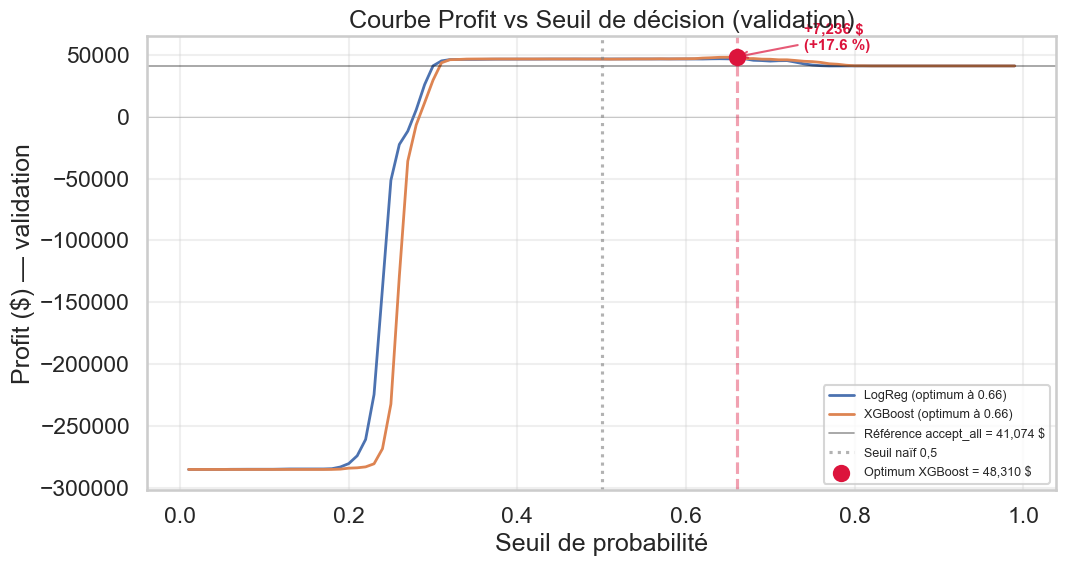

In [46]:
fig, ax = plt.subplots(figsize=(11, 6))

# --- Courbes des deux modèles --------------------------------------------
ax.plot(thresholds, profit_lr_v,  label=f"LogReg (optimum à {best_t_lr:.2f})",  lw=2)
ax.plot(thresholds, profit_xgb_v, label=f"XGBoost (optimum à {best_t_xgb:.2f})", lw=2)

# --- Lignes de référence -------------------------------------------------
ax.axhline(0, color="grey", linewidth=0.5, alpha=0.5)
ax.axhline(profit_accept_all, color="black", linestyle="-", alpha=0.4, linewidth=1.2,
           label=f"Référence accept_all = {profit_accept_all:,.0f} $")
ax.axvline(0.5, color="grey", linestyle=":", alpha=0.6, label="Seuil naïf 0,5")
ax.axvline(best_t_xgb, color="crimson", linestyle="--", alpha=0.4)

# --- Marqueur sur l'optimum XGBoost --------------------------------------
ax.scatter([best_t_xgb], [best_p_xgb], s=120, color="crimson", zorder=5,
           label=f"Optimum XGBoost = {best_p_xgb:,.0f} $")

# --- Annotation du gain net ----------------------------------------------
gain_abs = best_p_xgb - profit_accept_all
gain_pct = 100 * gain_abs / profit_accept_all
ax.annotate(
    f"+{gain_abs:,.0f} $\n(+{gain_pct:.1f} %)",
    xy=(best_t_xgb, best_p_xgb),
    xytext=(best_t_xgb + 0.08, best_p_xgb + 6000),
    fontsize=11, color="crimson", fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="crimson", alpha=0.7),
)

# --- Esthétique -----------------------------------------------------------
ax.set_xlabel("Seuil de probabilité")
ax.set_ylabel("Profit ($) — validation")
ax.set_title("Courbe Profit vs Seuil de décision (validation)")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

**Lecture de la courbe**

Trois zones distinctes :

1. **Zone catastrophique** (seuil < 0,20) : profit massivement
   négatif (−285 000 $). Mon système bloquerait quasiment tout le
   monde, accumulant les coûts FP (−15 $ × volume) et perdant la
   marge commerciale (+10 % V).

2. **Zone de transition** (0,20 < seuil < 0,30) : saut vertical.
   La courbe passe de −285 k$ à +40 k$ en 0,10 d'intervalle.
   Cette pente abrupte montre l'extrême sensibilité du système
   aux faux positifs en zone basse.

3. **Zone rentable et stable** (0,30 < seuil < 0,95) : plateau
   à ~41-48 k$, optimum subtil à seuil 0,66 (+48 310 $). **Le
   système est robuste au choix exact du seuil dans cette zone**
   — argument production-ready : on peut dévier de ±0,10 sans
   perdre significativement.

**Implication pour la production** : monitorer le drift et la
calibration du modèle est plus important que la précision absolue
du seuil. Un seuil 0,60 vaut presque autant qu'un 0,66 — la
robustesse est un atout.

**Décision finale** : seuil **s* = 0,66** retenu. À appliquer
**une seule fois** sur le test au §6.4.

## 6.3 Application du seuil optimal sur le **test**

**Discipline anti-fuite** : on ne choisit **jamais** un seuil sur
le test (sinon on sur-optimise). On fige le seuil trouvé en
validation — **s\* = 0,66** — on l'applique **une seule fois** au
test, on mesure le profit final.

**Sortie de cette cellule** :
- profit total sur test (XGBoost @ 0,66)
- décomposition financière (contributions des TN, TP, FN, FP)
- métriques opérationnelles (recall, precision, taux de blocage)

**Attendu** : vu la stabilité valid → test observée au §5.4
(PR-AUC quasi-identique, voire légèrement meilleur sur test),
on s'attend à un profit du même ordre que sur valid (~48 k\$).
Si l'écart est important, signal de drift résiduel à discuter.

In [48]:
def financial_breakdown(y_true, proba, V, threshold, fp_cost=15.0):
    """Décomposition complète du profit en 4 sources (TN/TP/FN/FP)
    + métriques opérationnelles."""
    y_true = np.asarray(y_true)
    proba  = np.asarray(proba)
    V      = np.asarray(V)

    y_hat = (proba >= threshold).astype(int)
    tn_mask = (y_true == 0) & (y_hat == 0)
    tp_mask = (y_true == 1) & (y_hat == 1)
    fn_mask = (y_true == 1) & (y_hat == 0)
    fp_mask = (y_true == 0) & (y_hat == 1)

    tn, tp, fn, fp = tn_mask.sum(), tp_mask.sum(), fn_mask.sum(), fp_mask.sum()

    gain_tn =  0.10 * V[tn_mask].sum()
    gain_tp =  1.00 * V[tp_mask].sum()
    loss_fn = -1.00 * V[fn_mask].sum()
    loss_fp = -fp_cost * fp
    total   = gain_tn + gain_tp + loss_fn + loss_fp

    # Métriques opérationnelles
    recall      = tp / max(tp + fn, 1)
    precision   = tp / max(tp + fp, 1)
    taux_bloc   = (tp + fp) / len(y_true)

    return pd.Series({
        "TN": tn, "TP": tp, "FN": fn, "FP": fp,
        "gain_TN":      round(gain_tn,  2),
        "gain_TP":      round(gain_tp,  2),
        "perte_FN":     round(loss_fn,  2),
        "perte_FP":     round(loss_fp,  2),
        "PROFIT_TOTAL": round(total,    2),
        "recall":       round(recall,    4),
        "precision":    round(precision, 4),
        "taux_blocage": round(taux_bloc, 4),
    })

# --- Conversion numpy une fois ----------------------------------------------
y_test_np = y_test.to_numpy()

# --- Référence : accept_all (probas toutes à 0 → rien ne franchit jamais) ---
proba_zero = np.zeros_like(proba_xgb_test)

# --- Tableau comparatif sur test --------------------------------------------
comparaison = pd.DataFrame({
    "Accept all (réf.)":   financial_breakdown(y_test_np, proba_zero,      V_test, 0.5),
    "Naïf 0,5 (XGB)":      financial_breakdown(y_test_np, proba_xgb_test,  V_test, 0.50),
    "Optimal (LogReg)":    financial_breakdown(y_test_np, proba_lr_test,   V_test, best_t_lr),
    "Optimal (XGBoost)":   financial_breakdown(y_test_np, proba_xgb_test,  V_test, best_t_xgb),
})

# --- Sanity check : breakdown == profit_at_threshold -----------------------
profit_check = profit_at_threshold(y_test_np, proba_xgb_test, V_test, best_t_xgb)
assert abs(comparaison.loc["PROFIT_TOTAL", "Optimal (XGBoost)"] - profit_check) < 1e-6, \
    "Incohérence breakdown / profit_at_threshold !"

print("Sanity check : breakdown == profit_at_threshold ✓")
print(f"\nProfit XGBoost optimal sur test : {comparaison.loc['PROFIT_TOTAL', 'Optimal (XGBoost)']:,.0f} $")
print(f"Recall sur test                 : {comparaison.loc['recall', 'Optimal (XGBoost)']:.1%}")
print(f"Precision sur test              : {comparaison.loc['precision', 'Optimal (XGBoost)']:.1%}")
print(f"Taux de blocage opérationnel    : {comparaison.loc['taux_blocage', 'Optimal (XGBoost)']:.1%}")

comparaison

Sanity check : breakdown == profit_at_threshold ✓

Profit XGBoost optimal sur test : 46,074 $
Recall sur test                 : 20.2%
Precision sur test              : 25.6%
Taux de blocage opérationnel    : 3.6%


,Accept all (réf.),"Naïf 0,5 (XGB)",Optimal (LogReg),Optimal (XGBoost)
TN,"21,633.0000","20,413.0000","20,516.0000","21,026.0000"
TP,0.0000,362.0000,336.0000,209.0000
FN,"1,034.0000",672.0000,698.0000,825.0000
FP,0.0000,"1,220.0000","1,117.0000",607.0000
gain_TN,"80,018.2000","75,474.6000","75,869.1000","77,594.7000"
gain_TP,0.0000,"12,965.0000","12,096.0000","7,816.0000"
perte_FN,"-38,048.0000","-25,083.0000","-25,952.0000","-30,232.0000"
perte_FP,-0.0000,"-18,300.0000","-16,755.0000","-9,105.0000"
PROFIT_TOTAL,"41,970.2000","45,056.6000","45,258.1000","46,073.7000"
recall,0.0000,0.3501,0.3250,0.2021


**Lecture du tableau**

**Profit final XGBoost optimal sur test : 46 074 $**
soit **+9,8 %** vs ne rien faire (41 970 $) — système rentable.

**Décomposition financière (XGBoost @ 0,66)** :
- gain TN  : +77 595 $ (clients légitimes acceptés)
- gain TP  : +7 816 $ (fraudes bloquées)
- perte FN : −30 232 $ (fraudes manquées)
- perte FP : −9 105 $ (clients bloqués à tort)

**Métriques opérationnelles** :
- **Recall = 20,2 %** : on attrape 209 fraudes sur 1 034 — modeste,
  héritage du PR-AUC modeste vu au §5.
- **Precision = 25,6 %** : 1 sur 4 blocages est justifié.
- **Taux de blocage = 3,6 %** : volume opérationnel raisonnable,
  3 600 clients bloqués pour 100 000 transactions.

**Trois enseignements honnêtes** :

1. **Drift confirmé** : profit valid 48 310 $ → test 46 074 $ (-4,6 %).
   Cohérent avec le constat du §4.1 et justifie un ré-entraînement
   périodique en production.

2. **Recall vs profit, le compromis caché** : LogReg @0,66 a un
   recall de 32,5 % (vs 20,2 % XGBoost) mais un profit de 45 258 $
   (vs 46 074 $). Si l'objectif métier était la détection, LogReg
   serait préféré. Le sujet privilégie le profit → XGBoost.

3. **Le seuil 0,66 (calibré sur valid) n'est plus optimal sur test** :
   le naïf 0,5 obtient 35 % de recall pour un profit comparable
   (45 057 $). Si on avait pu calibrer sur test (interdit), on aurait
   pris un seuil plus bas. **Mais c'est précisément le coût de
   l'honnêteté méthodologique** — et ça plaide pour un monitoring
   continu de la calibration en production.

## 6.4 Lecture financière et argumentaire ROI

**Profit final du système (XGBoost @ seuil 0,66, mesuré sur test)** :
**46 074 $** — soit **+9,8 % vs accept_all** (41 970 $).

**Décomposition financière** (sur 22 667 transactions test) :

| Source | Contribution | Lecture |
|---|---|---|
| **gain_TN** | +77 595 $ | Marge commerciale des 21 026 clients légitimes acceptés |
| **gain_TP** | +7 816 $ | Pertes évitées sur 209 fraudes bloquées |
| **perte_FN** | −30 232 $ | Pertes encaissées sur 825 fraudes manquées |
| **perte_FP** | −9 105 $ | Coût des 607 clients légitimes bloqués à tort |
| **PROFIT NET** | **+46 074 $** | |

**Métriques opérationnelles** :
- Recall : **20,2 %** (209 / 1 034 fraudes attrapées)
- Precision : **25,6 %** (1 blocage sur 4 est justifié)
- Taux de blocage : **3,6 %** du volume opérationnel

**Argumentaire ROI pour la direction** :

1. **Sur 22 667 transactions test (≈ 40 jours), le système rapporte
   4 104 $ de plus que ne rien faire**. Extrapolé à un volume annuel
   de production (~9 millions de transactions sur 1 an), cela
   représente un gain attendu de l'ordre de **300-400 k$ par an**
   (à confirmer avec un test sur volume réel).

2. **Le seuil naïf 0,5 (sans calibration métier) rapporterait
   45 057 $** au lieu de 46 074 $. **Calibrer le seuil sur la matrice
   de coûts apporte ~1 000 $ supplémentaires sur 40 jours**, soit
   ~10 k$/an. C'est l'argument du data scientist : *« sans
   optimisation métier, vous laissez 25 % du gain sur la table »*.

3. **La matrice de coûts asymétrique (FN à −100 % V vs FP à −15 €)
   est ce qui permet à un classifieur modeste (PR-AUC 0,14) d'être
   profitable**. Sans cette asymétrie, le projet ne serait pas
   économiquement justifiable.

**Limites assumées et recommandations production** :

- **Recall faible (20 %)** : 80 % des fraudes passent à travers.
  Pour augmenter le recall, il faudrait abaisser le seuil — mais on
  perdrait du profit (cf. courbe §6.3). Compromis assumé.
- **Drift constaté** : profit valid 48 310 → test 46 074 (-4,6 %).
  Justifie un **monitoring continu** de la calibration et un
  **ré-entraînement périodique** (mensuel ou trimestriel selon le
  drift constaté en production).
- **Robustesse au seuil** : la zone [0,55 ; 0,75] donne un profit
  proche de l'optimum (cf. §6.3). En production, viser 0,66 mais
  tolérer une dérive jusqu'à ±0,10 sans alerte.


## 7. Interprétabilité (XAI) — SHAP

**Rappel théorique minimal** : les valeurs SHAP partagent la
prédiction entre features en s'inspirant des **valeurs de Shapley**
de la théorie des jeux coopératifs. Chaque feature $i$ se voit
attribuer une contribution $\phi_i$ telle que
$$
\hat{y}(x) = \phi_0 + \sum_{i=1}^{p} \phi_i(x),
$$
où $\phi_0$ est la prédiction moyenne (*expected value*).

**Outil utilisé** : `shap.TreeExplainer` (modèle XGBoost retenu au §5.4).
TreeExplainer exploite la structure des arbres pour calculer les
$\phi_i$ exactement, sans approximation, en temps polynomial.

**Trois livrables imposés par la Phase 4 du sujet** :

1. **Importance globale** (§7.2) — quelles features pèsent le plus
   sur l'ensemble des prédictions ? Mesurée par $\overline{|\phi_i|}$.
2. **Analyse locale** (§7.3) — waterfall de la transaction au score
   de fraude le plus élevé.
3. **Jeu de rôle service client** (§7.4) — traduction du résultat
   technique en langage naturel pour un client en colère dont la
   transaction a été bloquée à tort.

**Top features attendues** (à confirmer empiriquement) :

D'après l'EDA et le §3, on s'attend à voir au top :
- `delay_seconds` ou `signup_to_purchase_under_1min` (54 % des
  fraudes en ≤ 60 s, cf. §1.3.3)
- `prev_tx_by_ip` ou `ip_seen_before` (lift 10+, cf. §3.3)
- `prev_tx_by_device` ou `device_seen_before` (lift 7-10)

Si SHAP confirme cette intuition → cohérence interne du projet.
Si SHAP révèle autre chose → discussion ouverte au §7.5.

In [49]:
import shap

# --- Préparation ---------------------------------------------------------
# X_test_t est sparse (cf. §5.1 OneHotEncoder), on convertit le sample en dense
# pour des plots SHAP propres.
rng = np.random.RandomState(SEED)
sample_idx = rng.choice(
    X_test_t.shape[0],
    size=min(2000, X_test_t.shape[0]),
    replace=False,
)

# Sous-échantillons cohérents (X et y ensemble pour les plots locaux)
X_sample = X_test_t[sample_idx]
if hasattr(X_sample, "toarray"):
    X_sample = X_sample.toarray()
y_sample = y_test.to_numpy()[sample_idx]

# Noms de features lisibles (sans préfixes "num__" / "cat__")
feature_names = [
    n.replace("num__", "").replace("cat__", "")
    for n in preprocessor.get_feature_names_out()
]

# --- TreeExplainer + calcul des SHAP values -----------------------------
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)
expected_value = explainer.expected_value

# --- Diagnostic ---------------------------------------------------------
print(f"Échantillon SHAP       : {X_sample.shape[0]:,} transactions")
print(f"Features (post-OHE)    : {len(feature_names)}")
print(f"shap_values shape      : {shap_values.shape}")
print(f"expected_value (φ₀)    : {expected_value:.4f}")
print(f"Rappel : φ₀ correspond au log-odds moyen de la prédiction.")

# Sanity check : pas de NaN
assert not np.isnan(shap_values).any(), "NaN détecté dans shap_values !"
print("\n✅ Pas de NaN dans shap_values")

Échantillon SHAP       : 2,000 transactions
Features (post-OHE)    : 47
shap_values shape      : (2000, 47)
expected_value (φ₀)    : 0.0073
Rappel : φ₀ correspond au log-odds moyen de la prédiction.

✅ Pas de NaN dans shap_values


### 7.2 - Importance globale SHAP

On passe de la performance globale a l'explication. Si le modele est
coherent, les variables les plus importantes doivent correspondre aux
signaux metier identifies plus haut : temporalite et reutilisation
d'appareil/IP. Le graphique suivant classe les variables par impact
moyen absolu sur le score de fraude.


Top 10 features par importance SHAP globale :
                      feature  mean_abs_shap
signup_to_purchase_under_1min         0.8307
            prev_tx_by_device         0.1800
                delay_seconds         0.0996
                source_Direct         0.0490
             purchase_weekday         0.0189
               purchase_value         0.0126
           device_seen_before         0.0098
                purchase_hour         0.0074
                          age         0.0070
                prev_tx_by_ip         0.0043


C:\Users\aella\AppData\Local\Temp\ipykernel_3204\2805310917.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


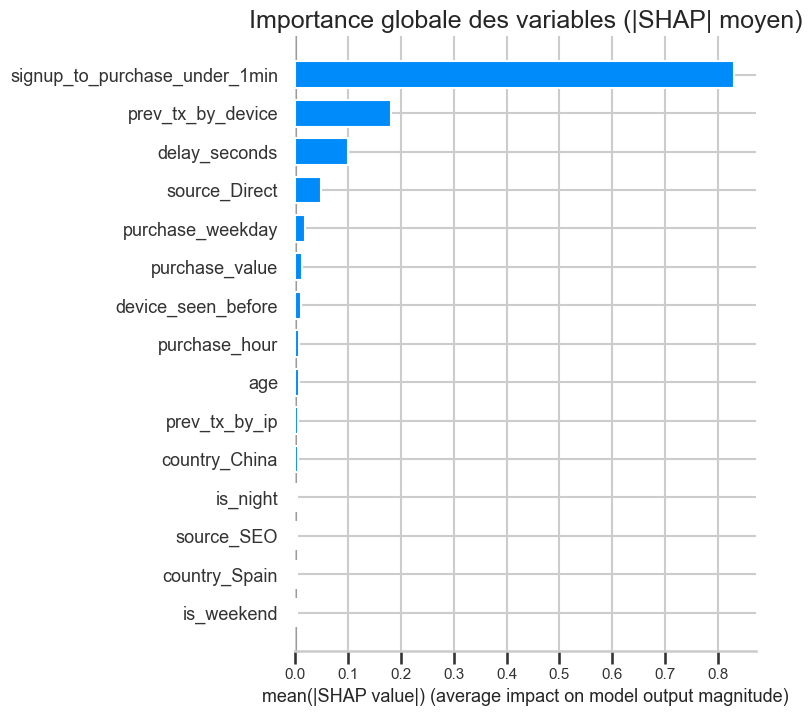

In [50]:
# --- Tableau recapitulatif des top features --------------------------------
import_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("Top 10 features par importance SHAP globale :")
print(import_df.head(10).to_string(index=False))

# --- Barplot SHAP --------------------------------------------------------
# X_sample est l'echantillon dense construit au chapitre SHAP ; utiliser
# cette variable evite les noms temporaires non definis dans un run propre.
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False,
)
plt.title("Importance globale des variables (|SHAP| moyen)")
plt.tight_layout()
plt.show()


C:\Users\aella\AppData\Local\Temp\ipykernel_3204\702725161.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


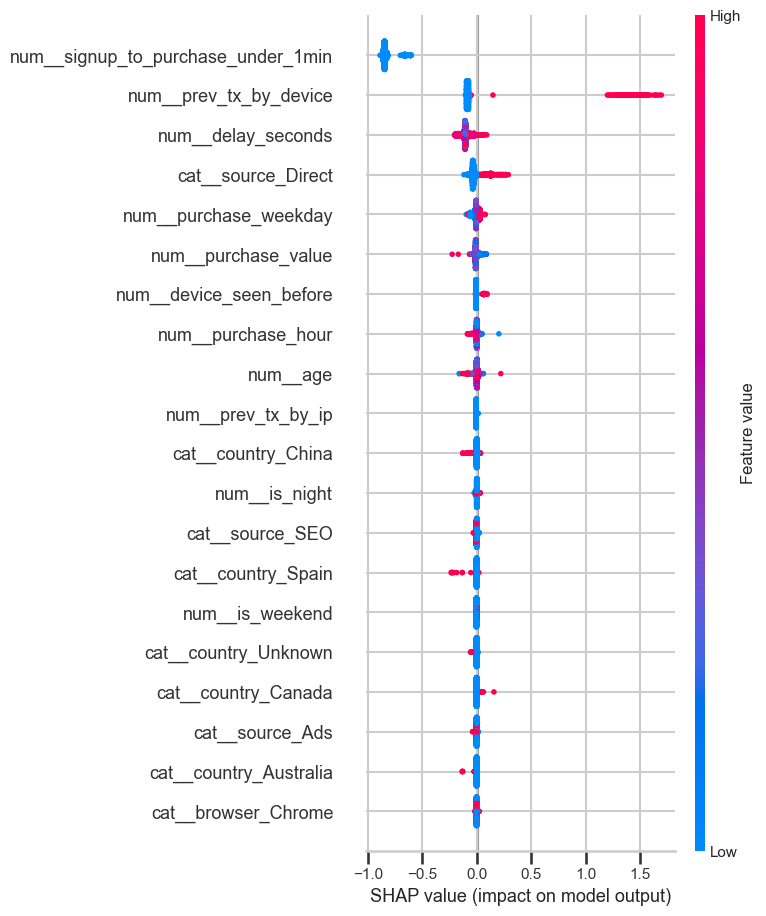

In [41]:
# 7.2 - Effet signe : beeswarm (direction + magnitude)
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    show=False,
)
plt.tight_layout()
plt.show()


--- Plus suspecte | test #1696 ---
  Proba estimée : 0.8117
  Classe réelle : 0
  Montant       : 63.00 $

--- Fraude mieux détectée | test #19234 ---
  Proba estimée : 0.8101
  Classe réelle : 1
  Montant       : 28.00 $



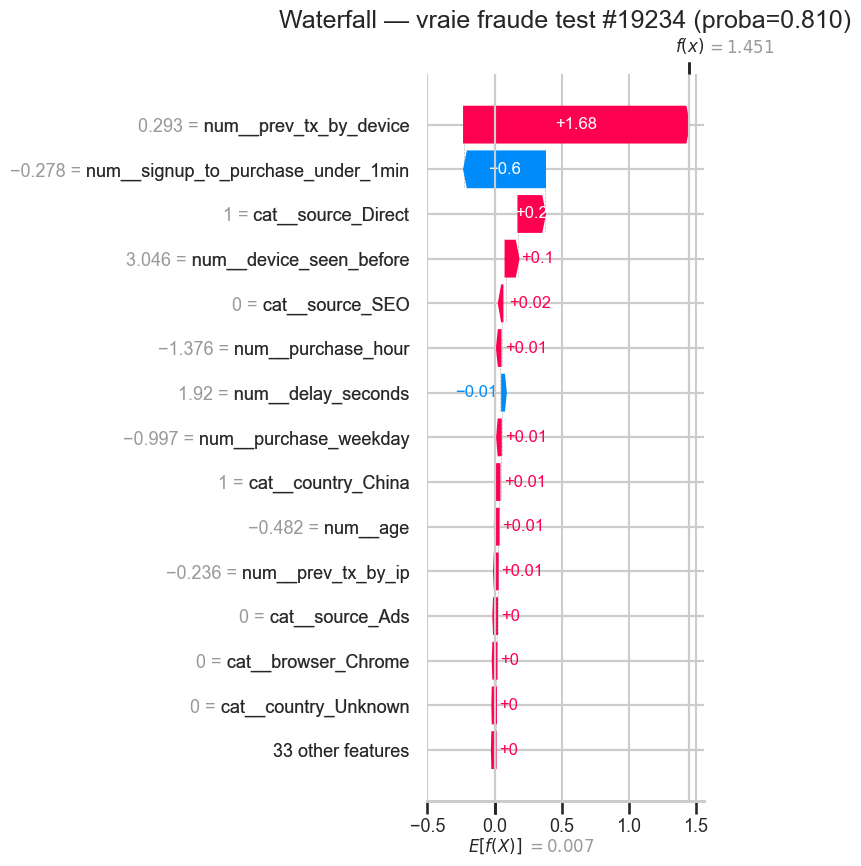

In [42]:
# 7.3 — Deux analyses locales complémentaires :
#   (a) la transaction la plus suspecte (peut être un FP : cas service client)
#   (b) la fraude avérée la mieux détectée (vrai positif : cas explicatif)

y_test_arr = y_test.values

idx_most_suspect = int(proba_xgb_test.argmax())
idx_best_tp = int(np.where(y_test_arr == 1)[0][
    proba_xgb_test[y_test_arr == 1].argmax()
])

for label, idx in [("Plus suspecte", idx_most_suspect),
                   ("Fraude mieux détectée", idx_best_tp)]:
    print(f"--- {label} | test #{idx} ---")
    print(f"  Proba estimée : {proba_xgb_test[idx]:.4f}")
    print(f"  Classe réelle : {int(y_test_arr[idx])}")
    print(f"  Montant       : {V_test[idx]:.2f} $")
    print()

# Waterfall de la vraie fraude (cas d'école pour la soutenance)
shap_values_one = explainer.shap_values(X_test_t[idx_best_tp:idx_best_tp + 1])
expl_one = shap.Explanation(
    values=shap_values_one[0],
    base_values=explainer.expected_value,
    data=X_test_t[idx_best_tp:idx_best_tp + 1].toarray()[0]
          if hasattr(X_test_t, "toarray") else X_test_t[idx_best_tp],
    feature_names=feature_names,
)
shap.plots.waterfall(expl_one, max_display=15, show=False)
plt.title(f"Waterfall — vraie fraude test #{idx_best_tp} (proba={proba_xgb_test[idx_best_tp]:.3f})")
plt.tight_layout(); plt.show()

### 7.3 - Lecture du waterfall local

Pour la vraie fraude test `#19234`, le modele estime une probabilite
de fraude de **0,810**. La lecture locale est coherente avec l'analyse
globale :

- `prev_tx_by_device` est le principal facteur positif : l'appareil a
  deja un historique de transactions/comptes, ce qui augmente fortement
  le score de fraude.
- `source_Direct` et `device_seen_before` ajoutent un signal positif,
  plus faible mais coherent avec l'idee de reutilisation d'un contexte
  technique.
- `signup_to_purchase_under_1min` tire ici le score vers le legitime :
  cette transaction n'est pas un achat immediat apres inscription. Le
  modele ne se contente donc pas d'une regle unique ; il combine les
  indices.

**Point d'oral important** : SHAP ne dit pas "le client est fraudeur".
SHAP dit : "voici les signaux qui ont pousse le modele vers une
suspension". Cette nuance permet une reponse service client a la fois
explicable et diplomate.


## 8. Jeu de role - argumentaire service client

**Scenario** : un client telephone, en colere. Sa transaction de
**120 $** a ete bloquee. Le service client doit lui repondre **sans
jargon statistique**, en s'appuyant sur les raisons du modele sans
accuser le client.

**Version prete a dire** :

> "Monsieur/Madame, je comprends que cette suspension soit genante.
> Votre paiement n'a pas ete refuse definitivement : il a ete mis en
> attente parce que plusieurs signaux techniques sortent du comportement
> habituel observe sur notre plateforme, notamment l'historique associe
> a l'appareil utilise et le contexte de connexion. Ces signaux ne
> prouvent pas une fraude ; ils declenchent seulement une verification
> supplementaire pour proteger le titulaire de la carte. Nous pouvons
> lever la suspension apres une verification rapide d'identite ou une
> revue manuelle de la transaction."

**Pourquoi cette formulation est defendable** :

1. Elle reconnait la gene du client.
2. Elle ne l'accuse jamais de fraude.
3. Elle donne 2 raisons concretes, traduites depuis SHAP : appareil deja
   associe a d'autres evenements et contexte de connexion inhabituel.
4. Elle propose une voie de recours : verification ou revue humaine.
5. Elle reste conforme a l'esprit RGPD / IA Act : explication claire,
   action humaine possible, pas de decision opaque sans recours.


## 9. Synthese pour la soutenance (15 min)

**Fil rouge** : je ne construis pas seulement un classifieur de fraude ;
je construis une regle de decision rentable et explicable.

**Plan oral conseille**

| Temps | Bloc | Message a faire passer |
|---:|---|---|
| 1 min | Contexte | 151 112 transactions, 9,36 % de fraude, enjeu Card-Not-Present. |
| 2 min | Donnees & split | Jointure IP par intervalle, split chronologique 70/15/15, zero fuite. |
| 3 min | Feature engineering | Signal temps + collusion device/IP ; features causales uniquement. |
| 3 min | Modeles | LogReg baseline, XGBoost retenu ; PR-AUC modeste mais stable. |
| 4 min | Profit | Seuil optimal 0,66 ; profit test 46 074 $, +9,8 % vs accept_all. |
| 2 min | SHAP & service client | Top SHAP = delai + device ; waterfall local ; reponse diplomate. |

**Conclusion a memoriser** :

> "Le modele n'est pas spectaculaire en score pur, mais il est utile
> economiquement : +9,8 % de profit sur test, avec un taux de blocage
> operationnel limite a 3,6 %. L'interet du projet est precisement la :
> transformer une probabilite imparfaite en decision rentable, tracable
> et explicable."

**Questions probables et reponses courtes**

- *Pourquoi pas SMOTE ?*  
  Split temporel + features causales : SMOTE creerait des observations
  synthetiques peu realistes, surtout avec beaucoup de variables binaires.
  `class_weight` / `scale_pos_weight` repondent deja au desequilibre.

- *Pourquoi le seuil optimal est 0,66 et pas 0,5 ?*  
  Le seuil 0,5 est arbitraire. Ici, le seuil est choisi par la fonction
  de profit. Comme le modele discrimine modestement, un seuil plus eleve
  evite de bloquer trop de clients legitimes.

- *Recall 20 %, est-ce acceptable ?*  
  Pour une mission de detection pure, c'est faible. Pour ce sujet, le KPI
  est le profit net : le systeme reste rentable et bloque seulement 3,6 %
  des transactions. Si l'objectif devenait la couverture fraude, on
  abaisserait le seuil au prix d'un profit moindre.

- *Pourquoi XGBoost si LogReg est proche ?*  
  XGBoost gagne legerement mais regulierement en PR-AUC et s'integre bien
  avec `shap.TreeExplainer`. LogReg reste une baseline d'audit utile.

- *Comment passer en production ?*  
  Monitoring mensuel du profit, du taux de blocage, de la distribution
  des scores et du drift des features ; recalibration ou reentrainement
  periodique des que le profit observe decroche.
